<a href="https://colab.research.google.com/github/Darya-06/python-ai-Aleinik-Darya/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `animated_television_series.csv` (4557 записей о 3461 анимационном сериале)
- Очищаем столбцы: переименовываем URL Wikidata (`serial` → `URL`), переименовываем `*Label` → короткие имена
- Анализируем структуру данных (числовые поля отсутствуют, работаем с категориальными данными)

**Результат:** Чистая таблица `df_series` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `serial` — название анимационного сериала
- `country` — страна производства
- `composer` — композитор
- `rarsRating` — возрастной рейтинг (0+, 6+, 12+, 16+, 18+)
- `derivativeWork` — производные работы (спин-оффы, адаптации)

**Особенности датасета:**
- Один сериал может быть представлен несколькими строками с разными странами (совместное производство)
- Много пропусков в данных: композитор (73%), рейтинг (97%), производные работы (93%)
- 98 стран-производителей, 462 композитора


In [15]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "Darya-06"
repo = "python-ai-Aleinik-Darya"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с анимационными сериалами
df_series = pd.read_csv("data/animated_television_series.csv")
print(f"📊 Загружено строк в df_series: {len(df_series)}\n")

# Шаг 3: Очистка данных для df_series
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_series = df_series.rename(columns={
    "serial": "URL",              # ← технический URL Wikidata
    "serialLabel": "serial",       # ← название сериала
    "countryLabel": "country",
    "composerLabel": "composer",
    "rarsRatingLabel": "rarsRating",
    "derivativeWorkLabel": "derivativeWork",
})
print("✅ df_series очищен\n")

# Краткий обзор датасета
print("📋 Структура df_series (анимационные сериалы):")
print(f"   Столбцы: {', '.join(df_series.columns)}")
print(f"   Уникальных сериалов: {df_series['serial'].nunique()}")
print(f"   Уникальных стран: {df_series['country'].nunique()}")
print(f"   Уникальных композиторов: {df_series['composer'].nunique()}")

# Анализ пропусков
missing = df_series.isnull().sum()
if missing.sum() > 0:
    print("\n📉 Пропуски в данных:")
    for col, count in missing[missing > 0].items():
        pct = count / len(df_series) * 100
        print(f"   • {col}: {count} ({pct:.1f}%)")

print(f"\n🔍 Первые 3 строки df_series:")
display(df_series.head(3))

print(f"\n🔍 Информация о типах данных:")
df_series.info()

✅ Репозиторий готов

📊 Загружено строк в df_series: 4557

✅ df_series очищен

📋 Структура df_series (анимационные сериалы):
   Столбцы: URL, serial, country, composer, rarsRating, derivativeWork
   Уникальных сериалов: 3461
   Уникальных стран: 98
   Уникальных композиторов: 462

📉 Пропуски в данных:
   • composer: 3344 (73.4%)
   • rarsRating: 4414 (96.9%)
   • derivativeWork: 4253 (93.3%)

🔍 Первые 3 строки df_series:


,URL,serial,country,composer,rarsRating,derivativeWork
0,http://www.wikidata.org/entity/Q77522,Клуб Винкс,Италия,Фабрицио Кастаниа,NaN,Клуб Винкс: Волшебное приключение
1,http://www.wikidata.org/entity/Q77522,Клуб Винкс,Италия,Фабрицио Кастаниа,NaN,Судьба: Сага Винкс
2,http://www.wikidata.org/entity/Q73622,Футурама,США,Кристофер Тинг,18+,NaN



🔍 Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4557 entries, 0 to 4556
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   URL             4557 non-null   object
 1   serial          4557 non-null   object
 2   country         4557 non-null   object
 3   composer        1213 non-null   object
 4   rarsRating      143 non-null    object
 5   derivativeWork  304 non-null    object
dtypes: object(6)
memory usage: 213.7+ KB


# **[1] Карта мира — кто с кем делает анимацию**

**Что показывает:** Международное сотрудничество в анимации — цвет стран (Viridis) показывает общее количество сериалов, дуги связывают страны-партнёры, толщина дуги — число совместных проектов.

**Когда использовать:** Для анализа глобальных связей в индустрии, выявления главных партнёров и географии производства.

**Библиотеки:** Plotly

**Особенность:** Интерактивные подсказки со списком сериалов при наведении на дугу

In [16]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ 1: КАРТА МИРА — КТО С КЕМ ДЕЛАЕТ АНИМАЦИЮ
# ============================================================================

# Устанавливаем необходимые библиотеки (если ещё не установлены)
!pip install -q plotly pycountry

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.offline import iplot
import pycountry
import math

print("✅ Библиотеки загружены\n")

# 1. ПОДГОТОВКА ДАННЫХ ------------------------------------------------------

# Проверяем, что df_series существует и загружен
if 'df_series' not in locals():
    print("⚠️ df_series не найден. Загружаем данные...")
    df_series = pd.read_csv("data/animated_television_series.csv")

    # Очистка данных, если ещё не сделана
    if "serialLabel" in df_series.columns:
        df_series = df_series.rename(columns={
            "serial": "URL",
            "serialLabel": "serial",
            "countryLabel": "country",
            "composerLabel": "composer",
            "rarsRatingLabel": "rarsRating",
            "derivativeWorkLabel": "derivativeWork",
        })
        print("✅ Данные очищены")

# Словарь столиц для топ-стран по анимации (включая все страны из наших данных)
capitals = {
    'США': ('Washington D.C.', 38.9072, -77.0369),
    'Великобритания': ('London', 51.5074, -0.1278),
    'Канада': ('Ottawa', 45.4215, -75.6972),
    'Франция': ('Paris', 48.8566, 2.3522),
    'Германия': ('Berlin', 52.5200, 13.4050),
    'Япония': ('Tokyo', 35.6762, 139.6503),
    'Китай': ('Beijing', 39.9042, 116.4074),
    'Республика Корея': ('Seoul', 37.5665, 126.9780),
    'Италия': ('Rome', 41.9028, 12.4964),
    'Австралия': ('Canberra', -35.2809, 149.1300),
    'Россия': ('Moscow', 55.7558, 37.6173),
    'Испания': ('Madrid', 40.4168, -3.7038),
    'Бельгия': ('Brussels', 50.8503, 4.3517),
    'Индия': ('New Delhi', 28.6139, 77.2090),
    'Бразилия': ('Brasilia', -15.8267, -47.9218),
    'Польша': ('Warsaw', 52.2297, 21.0122),
    'Ирландия': ('Dublin', 53.3498, -6.2603),
    'Чехия': ('Prague', 50.0755, 14.4378),
    'Венгрия': ('Budapest', 47.4979, 19.0402),
    'Дания': ('Copenhagen', 55.6761, 12.5683),
    'Швеция': ('Stockholm', 59.3293, 18.0686),
    'Норвегия': ('Oslo', 59.9139, 10.7522),
    'Финляндия': ('Helsinki', 60.1699, 24.9384),
    'Нидерланды': ('Amsterdam', 52.3676, 4.9041),
    'Австрия': ('Vienna', 48.2082, 16.3738),
    'Швейцария': ('Bern', 46.9480, 7.4474),
    'Мексика': ('Mexico City', 19.4326, -99.1332),
    'Аргентина': ('Buenos Aires', -34.6037, -58.3816),
    'ЮАР': ('Pretoria', -25.7461, 28.1881),
    'Новая Зеландия': ('Wellington', -41.2865, 174.7762),
    'Индонезия': ('Jakarta', -6.2088, 106.8456),
    'Таиланд': ('Bangkok', 13.7563, 100.5018),
    'Сингапур': ('Singapore', 1.3521, 103.8198),
    'Кипр': ('Nicosia', 35.1856, 33.3823),
    'Словения': ('Ljubljana', 46.0569, 14.5058),
    'Чехословакия': ('Prague', 50.0755, 14.4378),  # Используем Прагу
    'Лихтенштейн': ('Vaduz', 47.1410, 9.5209),
    'Китайская Республика (Тайвань)': ('Taipei', 25.0330, 121.5654),
    'Северная Македония': ('Skopje', 41.9973, 21.4280),
    'Исландия': ('Reykjavik', 64.1466, -21.9426),
    'Колумбия': ('Bogota', 4.7110, -74.0721),
    'Португалия': ('Lisbon', 38.7223, -9.1393),
    'Чили': ('Santiago', -33.4489, -70.6693),
}

print(f"📊 Всего стран в данных: {df_series['country'].nunique()}")
print(f"📊 Всего уникальных сериалов: {df_series['URL'].nunique()}")

# 2. СЧИТАЕМ КОЛИЧЕСТВО СЕРИАЛОВ ПО СТРАНАМ --------------------------------
# (по уникальным URL, чтобы не дублировать)

# Получаем уникальные пары (URL, страна)
unique_series_country = df_series[['URL', 'country']].drop_duplicates()

# Считаем количество уникальных сериалов на страну
country_counts = unique_series_country.groupby('country').size().reset_index(name='count')
country_counts = country_counts.sort_values('count', ascending=False)

print("\nТоп-10 стран по числу сериалов:")
print(country_counts.head(10))

# Добавляем логарифмическую шкалу (log10)
country_counts['log_count'] = np.log10(country_counts['count'])

# 3. СЧИТАЕМ СОВМЕСТНЫЕ ПРОЕКТЫ (ПАРЫ СТРАН) -----------------------------

# Создаем список всех совместных проектов
collaborations = []

# Группируем по URL сериала
for url, group in df_series.groupby('URL'):
    countries = group['country'].unique()
    if len(countries) >= 2:
        # Для каждой пары стран в этом сериале
        for i in range(len(countries)):
            for j in range(i+1, len(countries)):
                pair = tuple(sorted([countries[i], countries[j]]))
                collaborations.append({
                    'country1': pair[0],
                    'country2': pair[1],
                    'serial': group['serial'].iloc[0]  # название сериала
                })

# Создаем DataFrame коллабораций
collab_df = pd.DataFrame(collaborations)

# Считаем количество совместных проектов для каждой пары
pair_counts = collab_df.groupby(['country1', 'country2']).size().reset_index(name='count')
pair_counts = pair_counts.sort_values('count', ascending=False)

# Фильтруем: только пары с 2+ совместными проектами (снизим порог для наглядности)
pair_counts_filtered = pair_counts[pair_counts['count'] >= 2]

print(f"\nНайдено {len(pair_counts_filtered)} пар стран с 2+ совместными проектами")
print("Топ-5 пар:")
print(pair_counts_filtered.head(5))

# 4. ДОБАВЛЯЕМ КООРДИНАТЫ СТОЛИЦ -----------------------------------------

def get_coords(country):
    """Получить координаты столицы страны из словаря"""
    if country in capitals:
        return capitals[country][1], capitals[country][2]
    else:
        return None, None

# Исправляем предупреждение: создаём явную копию перед изменениями
pair_counts_filtered = pair_counts_filtered.copy()

# Теперь безопасно добавляем новые столбцы
pair_counts_filtered['lat1'] = pair_counts_filtered['country1'].apply(lambda x: get_coords(x)[0])
pair_counts_filtered['lon1'] = pair_counts_filtered['country1'].apply(lambda x: get_coords(x)[1])
pair_counts_filtered['lat2'] = pair_counts_filtered['country2'].apply(lambda x: get_coords(x)[0])
pair_counts_filtered['lon2'] = pair_counts_filtered['country2'].apply(lambda x: get_coords(x)[1])

# Удаляем пары с отсутствующими координатами
pair_counts_filtered = pair_counts_filtered.dropna(subset=['lat1', 'lon1', 'lat2', 'lon2'])

print(f"\nПосле фильтрации по координатам осталось {len(pair_counts_filtered)} пар")

# 5. РАСЧЁТ РАССТОЯНИЙ И ПОДГОТОВКА ПОДПИСЕЙ -----------------------------

def haversine(lat1, lon1, lat2, lon2):
    """Расстояние между двумя точками на сфере в км"""
    R = 6371  # радиус Земли в км
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Считаем расстояние для каждой пары
pair_counts_filtered['distance'] = pair_counts_filtered.apply(
    lambda row: haversine(row['lat1'], row['lon1'], row['lat2'], row['lon2']), axis=1
)

# Для длинных дуг (>3000 км) собираем названия сериалов
def get_series_titles(country1, country2, max_titles=3):
    """Получить названия сериалов для пары стран (первые по алфавиту)"""
    titles = []
    for url, group in df_series.groupby('URL'):
        countries = set(group['country'])
        if country1 in countries and country2 in countries:
            titles.append(group['serial'].iloc[0])
    # Сортируем и берем первые max_titles
    titles = sorted(titles)[:max_titles]
    return '<br>'.join(titles) if titles else ''

# Применяем функцию только для длинных дуг
pair_counts_filtered['titles'] = pair_counts_filtered.apply(
    lambda row: get_series_titles(row['country1'], row['country2'])
    if row['distance'] > 3000 else '', axis=1
)

# 6. СОЗДАЁМ ИНТЕРАКТИВНУЮ КАРТУ -----------------------------------------

fig = go.Figure()

# Слой 1: Хороплет (цвет стран по числу сериалов)
fig.add_trace(go.Choropleth(
    locations=country_counts['country'],
    locationmode='country names',
    z=country_counts['log_count'],
    text=country_counts['country'],
    hovertext=country_counts.apply(
        lambda row: f"<b>{row['country']}</b><br>Сериалов: {row['count']}<br>log10: {row['log_count']:.2f}",
        axis=1
    ),
    hoverinfo='text',
    colorscale='Viridis',  # Хорошая контрастность и цветовая дифференциация
    autocolorscale=False,
    reversescale=False,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_title="log10(число сериалов)",
    zmin=0,
    zmax=country_counts['log_count'].max(),
    showscale=True
))

# Слой 2: Дуги между странами
for _, row in pair_counts_filtered.iterrows():
    # Создаем дугу (простая линия с изгибом)
    # Используем параболическую дугу для лучшей визуализации

    # Количество точек для дуги
    n_points = 50

    # Параметры дуги
    lat1, lon1 = row['lat1'], row['lon1']
    lat2, lon2 = row['lat2'], row['lon2']

    # Средняя точка с изгибом
    mid_lat = (lat1 + lat2) / 2
    mid_lon = (lon1 + lon2) / 2

    # Добавляем изгиб пропорционально расстоянию
    distance = row['distance']
    bulge = min(distance / 2000, 20)  # Максимальный изгиб 20 градусов

    # Для南北半球的 коррекция изгиба
    if abs(lat1 - lat2) > 30:  # Если большой разброс по широте
        bulge = bulge * 1.5

    mid_lat = mid_lat + bulge

    # Создаем квадратичную кривую Безье
    t = np.linspace(0, 1, n_points)
    lats = (1-t)**2 * lat1 + 2*(1-t)*t * mid_lat + t**2 * lat2
    lons = (1-t)**2 * lon1 + 2*(1-t)*t * mid_lon + t**2 * lon2

    # Толщина и прозрачность линии пропорциональны числу совместных проектов
    width = 1 + row['count'] * 1.5
    opacity = min(0.4 + row['count'] * 0.1, 0.9)

    # Цвет линии: красный с прозрачностью
    color = f'rgba(255, 80, 80, {opacity})'

    fig.add_trace(go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"<b>{row['country1']} — {row['country2']}</b><br>Совместных проектов: {row['count']}",
        showlegend=False,
        name=f"{row['country1']} — {row['country2']}"
    ))

    # Слой 3: Подписи на длинных дугах
    if row['titles'] and row['distance'] > 3000:
        # Точка на 40% пути (чтобы подпись не попадала точно на столицы)
        mid_idx = int(n_points * 0.4)

        # Добавляем подпись с названиями мультфильмов
        fig.add_trace(go.Scattergeo(
            lon=[lons[mid_idx] + 2],
            lat=[lats[mid_idx] - 2],
            mode='text',
            text=[f"<b>{row['country1']} — {row['country2']}</b><br><span style='font-size:8pt'>{row['titles']}</span>"],
            textposition='middle center',
            textfont=dict(size=9, color='darkred'),
            hoverinfo='none',
            showlegend=False
        ))

# Настройка макета
fig.update_layout(
    title=dict(
        text='🌍 Карта мира — кто с кем делает анимацию',
        font=dict(size=24, family='Arial'),
        x=0.5,
        xanchor='center'
    ),
    geo=dict(
        showframe=True,
        showcoastlines=True,
        projection_type='natural earth',
        coastlinecolor='lightgray',
        landcolor='rgb(240, 240, 240)',
        showland=True,
        showcountries=True,
        countrycolor='darkgray',
        countrywidth=0.5,
        lataxis=dict(range=[-60, 80]),  # Ограничиваем широту, чтобы не показывать Антарктиду
        showocean=True,
        oceancolor='rgb(200, 220, 240)'
    ),
    height=700,
    width=1200,
    margin=dict(l=0, r=0, t=60, b=0),
    showlegend=False,
    hovermode='closest'
)

fig.show()

# Сохраняем как HTML для вставки в ноутбук
fig.write_html("animation_world_map.html")
print("\n✅ Карта сохранена как animation_world_map.html")
print("✅ Для просмотра в Colab: используйте интерактивную карту выше")

✅ Библиотеки загружены

📊 Всего стран в данных: 98
📊 Всего уникальных сериалов: 3498

Топ-10 стран по числу сериалов:
             country  count
70               США   1568
85           Франция    436
37            Канада    381
11    Великобритания    280
65  Республика Корея    213
41             Китай    208
33            Италия    122
32           Испания     99
66            Россия     91
17          Германия     77

Найдено 101 пар стран с 2+ совместными проектами
Топ-5 пар:
           country1 country2  count
186          Канада      США    126
190          Канада  Франция     62
262             США  Франция     43
70   Великобритания      США     33
266             США   Япония     26

После фильтрации по координатам осталось 92 пар



✅ Карта сохранена как animation_world_map.html
✅ Для просмотра в Colab: используйте интерактивную карту выше


## 💬 Фидбек AI 1: Карта мира — общая оценка и предложения по улучшению

Теперь взгляни на визуализацию, что по твоему мнению ты бы хотел в ней изменить, отредактировать?

## 💬 Фидбек AI 2: Карта мира — убрать визуальный шум

Хоть визуализация стала и менее нагруженная, но всё же создает визуальный шум, что бы ты изменил для более привлекательного вида?

## 💬 Фидбек AI 3: Карта мира — вернуть цветовую шкалу и поправить легенду

Карта стала более наглядной, но легенда перекрывает шкалу, и шкала стала не той, которая задавалась изначально по цветовой гамме



## 💬 Фидбек AI 4: Карта мира — добавить названия сериалов

Почему где-то есть названия мультсериалов, а где-то нет, и изначально было условие о том, что названия сериалов должны присутствовать на визуализации, проанализируй, как можно более привлекательно и информативно улучшить карту?


## 💬 Фидбек AI 5: Карта мира — исправить ошибку с сохранением списков в DataFrame

Визуализация не получилась, вот выходные ячейки ошибки: ValueError: Must have equal len keys and value when setting with an iterable

In [ ]:
# ============================================================================
# УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ - С НАЗВАНИЯМИ СЕРИАЛОВ (ИСПРАВЛЕННАЯ)
# ============================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. БЕРЁМ ТОП-7 ПАР
top_n = 7
top_pairs = pair_counts_filtered.nlargest(top_n, 'count').copy()

# 2. ФУНКЦИЯ ДЛЯ ПОЛУЧЕНИЯ ВСЕХ НАЗВАНИЙ СЕРИАЛОВ ПАРЫ
def get_all_series_titles(country1, country2, max_titles=10):
    """Получить ВСЕ названия сериалов для пары стран (отсортированные)"""
    titles = []
    for url, group in df_series.groupby('URL'):
        countries = set(group['country'])
        if country1 in countries and country2 in countries:
            title = group['serial'].iloc[0]
            if title and not title.startswith('Q'):  # Исключаем Q-коды
                titles.append(title)

    # Сортируем по алфавиту и убираем дубликаты
    titles = sorted(set(titles))

    if not titles:  # Если нет нормальных названий
        return ["(нет данных)"]

    return titles[:max_titles]  # Возвращаем максимум 10 названий

# 3. СОБИРАЕМ НАЗВАНИЯ В ОТДЕЛЬНЫЙ СЛОВАРЬ (НЕ В DATAFRAME!)
print("📚 Собираем названия сериалов для каждой пары:")

# Создаём словари для хранения названий
titles_dict = {}  # Для хранения всех названий
titles_preview_dict = {}  # Для хранения превью (первые 3)

for idx, row in top_pairs.iterrows():
    titles = get_all_series_titles(row['country1'], row['country2'], max_titles=10)

    # Сохраняем в словарь с ключом в виде пары стран
    pair_key = f"{row['country1']}—{row['country2']}"
    titles_dict[pair_key] = titles
    titles_preview_dict[pair_key] = ', '.join(titles[:3])

    print(f"\n{row['country1']} — {row['country2']}:")
    for i, title in enumerate(titles[:5], 1):
        print(f"   {i}. {title}")
    if len(titles) > 5:
        print(f"   ... и ещё {len(titles)-5}")

# 4. ЦВЕТОВАЯ СХЕМА ДЛЯ ДУГ
colors = [
    'rgba(231, 76, 60, 0.9)',   # коралловый
    'rgba(52, 152, 219, 0.9)',  # небесно-голубой
    'rgba(46, 204, 113, 0.9)',  # изумрудный
    'rgba(155, 89, 182, 0.9)',  # лавандовый
    'rgba(241, 196, 15, 0.9)',  # золотой
    'rgba(230, 126, 34, 0.9)',  # мандариновый
    'rgba(149, 165, 166, 0.9)'  # серый
]

# 5. СОЗДАЁМ КАРТУ
fig = go.Figure()

# Слой 1: Хороплет (Viridis)
fig.add_trace(go.Choropleth(
    locations=country_counts['country'],
    locationmode='country names',
    z=country_counts['log_count'],
    colorscale='Viridis',
    zmin=0,
    zmax=country_counts['log_count'].max(),
    marker_line_color='white',
    marker_line_width=0.5,
    colorbar=dict(
        title="log10(число сериалов)",
        titleside='right',
        x=1.02,
        xpad=10,
        y=0.5,
        len=0.8,
        bgcolor='rgba(255,255,255,0.8)'
    ),
    showscale=True,
    hoverinfo='text',
    hovertext=country_counts.apply(
        lambda row: f"<b>{row['country']}</b><br>🎬 Сериалов: {row['count']}<br>📊 log10: {row['log_count']:.2f}",
        axis=1
    )
))

# Слой 2: Дуги с улучшенными tooltip
for idx, (_, row) in enumerate(top_pairs.iterrows()):
    # Получаем названия из словаря
    pair_key = f"{row['country1']}—{row['country2']}"
    titles = titles_dict.get(pair_key, ["(нет данных)"])

    # Параметры дуги
    lat1, lon1 = row['lat1'], row['lon1']
    lat2, lon2 = row['lat2'], row['lon2']

    # Создаём дугу
    n_points = 100
    mid_lat = (lat1 + lat2) / 2
    mid_lon = (lon1 + lon2) / 2

    distance = row['distance']
    bulge = min(distance / 5000, 8)
    mid_lat = mid_lat + bulge

    t = np.linspace(0, 1, n_points)
    lats = (1-t)**2 * lat1 + 2*(1-t)*t * mid_lat + t**2 * lat2
    lons = (1-t)**2 * lon1 + 2*(1-t)*t * mid_lon + t**2 * lon2

    # Формируем красивый tooltip
    titles_html = "<br>".join([f"   • {title}" for title in titles[:8]])
    if len(titles) > 8:
        titles_html += f"<br>   ... и ещё {len(titles)-8}"

    hover_text = (
        f"<b>🌍 {row['country1']} — {row['country2']}</b><br>"
        f"<b>📊 Совместных проектов: {row['count']}</b><br>"
        f"<b>📏 Расстояние: {int(distance)} км</b><br>"
        f"<br>"
        f"<b>🎬 Примеры сериалов:</b><br>"
        f"{titles_html}"
    )

    # Glow-эффект (полупрозрачная подложка)
    fig.add_trace(go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='lines',
        line=dict(width=row['count'] * 0.8 + 5, color=f'rgba(200,200,200,0.15)'),
        hoverinfo='none',
        showlegend=False
    ))

    # Основная линия
    fig.add_trace(go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='lines',
        line=dict(width=row['count'] * 0.5 + 2, color=colors[idx % len(colors)]),
        hoverinfo='text',
        hovertext=hover_text,
        hoverlabel=dict(
            bgcolor='white',
            font_size=11,
            font_family='Arial',
            bordercolor=colors[idx % len(colors)],
            font_color='black'
        ),
        showlegend=False
    ))

# Слой 3: Точки в столицах
for country in set(top_pairs['country1'].tolist() + top_pairs['country2'].tolist()):
    if country in capitals:
        lat, lon = capitals[country][1], capitals[country][2]

        # Считаем общее количество проектов для страны
        country_total = country_counts[country_counts['country'] == country]['count'].values
        country_total = country_total[0] if len(country_total) > 0 else 0

        fig.add_trace(go.Scattergeo(
            lon=[lon],
            lat=[lat],
            mode='markers+text',
            marker=dict(
                size=12,
                color='white',
                line=dict(width=2, color='#e74c3c')
            ),
            text=[country[:3].upper()],  # Код страны (USA, CAN, etc.)
            textposition='bottom center',
            textfont=dict(size=9, color='black', weight='bold'),
            hoverinfo='text',
            hovertext=f"<b>{country}</b><br>Всего сериалов: {country_total}",
            showlegend=False
        ))

# 6. ЛЕГЕНДА СЛЕВА (с названиями)
legend_x = -0.15
legend_y = 0.98

legend_text = "<b>🌍 Топ-7 анимационных коллабораций:</b><br><br>"
for idx, (_, row) in enumerate(top_pairs.iterrows()):
    pair_key = f"{row['country1']}—{row['country2']}"
    preview = titles_preview_dict.get(pair_key, "")

    legend_text += f"{idx+1}. <span style='color:{colors[idx % len(colors)]}'>●</span> "
    legend_text += f"<b>{row['country1']} — {row['country2']}</b><br>"
    legend_text += f"&nbsp;&nbsp;&nbsp;📊 {row['count']} проектов<br>"

    # Добавляем пример сериала (первый из списка)
    if preview:
        first_title = preview.split(',')[0]
        if len(first_title) > 25:
            first_title = first_title[:23] + '…'
        legend_text += f"&nbsp;&nbsp;&nbsp;🎬 <i>«{first_title}»</i><br>"
    legend_text += "<br>"

legend_text += "<b>🎨 Цветовая шкала:</b><br>"
legend_text += "&nbsp;&nbsp;Viridis (тёмный → жёлтый)<br>"
legend_text += "&nbsp;&nbsp;Чем ярче страна, тем больше сериалов<br><br>"
legend_text += "<b>ℹ️ Как пользоваться:</b><br>"
legend_text += "• Наведите на дугу → все сериалы пары<br>"
legend_text += "• Наведите на страну → статистика"

fig.add_annotation(
    x=legend_x,
    y=legend_y,
    xref="paper",
    yref="paper",
    text=legend_text,
    showarrow=False,
    font=dict(size=11, family='Arial'),
    align='left',
    bgcolor='rgba(255, 255, 255, 0.95)',
    bordercolor='lightgray',
    borderwidth=1,
    borderpad=12,
    xanchor='left',
    yanchor='top'
)

# Настройка макета
fig.update_layout(
    title=dict(
        text='🌍 Карта мира — главные анимационные коллаборации',
        font=dict(size=26, family='Arial', color='#2c3e50'),
        x=0.5
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        projection_type='natural earth',
        landcolor='rgb(245, 245, 245)',
        showland=True,
        showcountries=True,
        countrycolor='lightgray',
        countrywidth=0.3,
        lataxis=dict(range=[-60, 80]),
        showocean=True,
        oceancolor='rgb(230, 240, 250)'
    ),
    height=750,
    width=1300,
    margin=dict(l=280, r=50, t=70, b=30),
    hovermode='closest',
    hoverdistance=100
)

# Сохраняем
fig.write_html("animation_world_map_fixed.html")
print("\n✅ Карта успешно создана!")
print("📁 Файл сохранён: animation_world_map_fixed.html")

# Показываем в Colab
fig.show()

📚 Собираем названия сериалов для каждой пары:

Канада — США:
   1. Action Pack
   2. Angela Anaconda
   3. Aртур (телесериал)
   4. Barney's World
   5. Corduroy
   ... и ещё 5

Канада — Франция:
   1. Anatane: Saving the Children of Okura
   2. Ariol
   3. Belle and Sebastian
   4. Billy the Cat
   5. Blake and Mortimer
   ... и ещё 5

США — Франция:
   1. Cosmic Quantum Ray
   2. Kiya & the Kimoja Heroes
   3. Lalaloopsy
   4. Lucky Luke
   5. Mighty Max
   ... и ещё 5

Великобритания — США:
   1. Angry Birds: Летнее безумие
   2. Blippi And Sesame Street Adventures
   3. Clifford the Big Red Dog
   4. Fantastic Max
   5. Henry Hugglemonster
   ... и ещё 5

США — Япония:
   1. Bearbrick
   2. Dino Girl Gauko
   3. Domo-kun
   4. Eagle Riders
   5. G.I. Joe: Sigma 6
   ... и ещё 5

Китай — Республика Корея:
   1. Bubble's Hotel
   2. Bugsbot Ignition
   3. Dino Powers
   4. Let's Go! Galaxy Guards
   5. Let's Gorilla!
   ... и ещё 5

Великобритания — Франция:
   1. Billy the Cat
   2.

**💡 Инсайт из предыдущего графика:** В России больше мультфильмов, чем в Дании, но за какой период истории?

## 📊 [2] Horizontal Bar Chart: Top 15 Genres

**Что показывает:**  
Самые популярные жанры в мультипликации. Лидируют приключенческие, комедийные и фэнтезийные фильмы.

**Когда использовать:**  
Когда у категорий длинные названия — горизонтальный график читается лучше, чем вертикальный с повёрнутыми подписями.

**Библиотеки:** `matplotlib`

**Метод:** `plt.barh()` — horizontal bar chart (горизонтальная столбчатая диаграмма).

In [17]:
for rating in ['0+', '6+', '12+', '18+']:
    subset = df_series[df_series['rarsRating'] == rating]
    unique_serials = subset['URL'].nunique()
    all_words = ' '.join(subset['serial'].dropna()).lower().split()
    print(f"Рейтинг {rating}: {unique_serials} уникальных сериалов, {len(all_words)} слов в тексте")

Рейтинг 0+: 36 уникальных сериалов, 119 слов в тексте
Рейтинг 6+: 22 уникальных сериалов, 116 слов в тексте
Рейтинг 12+: 21 уникальных сериалов, 81 слов в тексте
Рейтинг 18+: 14 уникальных сериалов, 25 слов в тексте


Для рейтинга 18+ данных **14** сериалов — облако будет скромным, но для учебного анализа достаточно

📊 Готовим облака слов для каждого рейтинга...

Рейтинг 0+: 36 сериалов
Рейтинг 6+: 22 сериалов
Рейтинг 12+: 21 сериалов
Рейтинг 18+: 14 сериалов


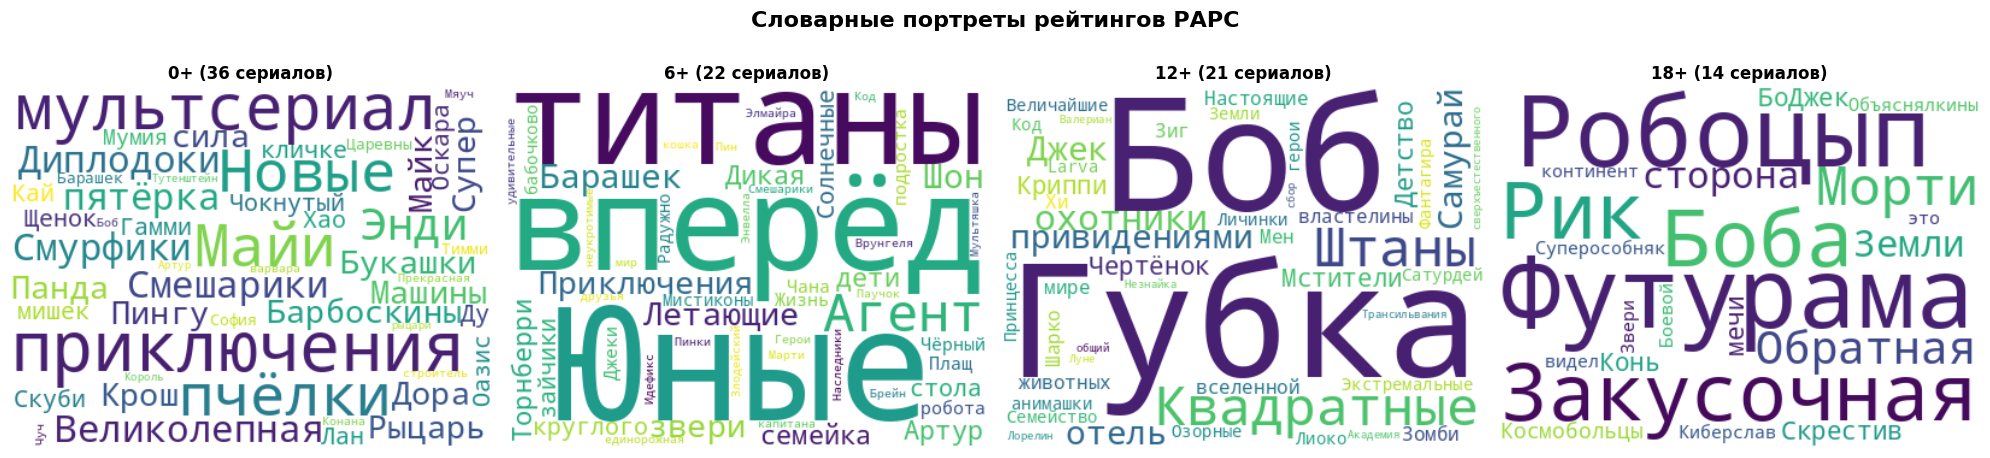


✅ Базовые облака слов созданы

📈 Топ-10 самых частых слов по рейтингам:
--------------------------------------------------

0+:
  приключения: 8
  мультсериал: 7
  новые: 6
  пчёлки: 6
  майи: 6
  энди: 3
  смешарики: 2
  великолепная: 2
  пятёрка: 2
  смурфики: 2

6+:
  юные: 10
  титаны: 10
  вперёд: 10
  агент: 5
  барашек: 3
  шон: 3
  приключения: 3
  летающие: 3
  звери: 3
  дикая: 2

12+:
  губка: 6
  боб: 6
  квадратные: 6
  штаны: 6
  охотники: 2
  привидениями: 2
  отель: 2
  самурай: 2
  джек: 2
  чертёнок: 2

18+:
  футурама: 1
  робоцып: 1
  закусочная: 1
  боба: 1
  рик: 1
  морти: 1
  обратная: 1
  сторона: 1
  земли: 1
  скрестив: 1


In [18]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ 2: СЛОВАРНЫЕ ПОРТРЕТЫ РЕЙТИНГОВ — ШАГ 1 (БАЗОВЫЕ ОБЛАКА)
# ============================================================================

# Устанавливаем wordcloud если ещё не установлен
!pip install -q wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Загружаем стоп-слова
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Создаём список стоп-слов (русские + английские)
stop_words = set(stopwords.words('russian') + stopwords.words('english'))
custom_stops = set(['и', 'в', 'на', 'с', 'со', 'к', 'у', 'по', 'за', 'из', 'от',
                    'the', 'of', 'a', 'an', 'to', 'and', 'in', 'for', 'is', 'on'])

stop_words = stop_words.union(custom_stops)

print("📊 Готовим облака слов для каждого рейтинга...\n")

# Получаем уникальные значения рейтингов
ratings = ['0+', '6+', '12+', '18+']
rating_names = ['0+ (детский)', '6+ (младший школьный)', '12+ (подростковый)', '18+ (взрослый)']

# Создаём фигуру с 4 субплотами
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Словарные портреты рейтингов РАРС', fontsize=16, fontweight='bold')

# Для каждого рейтинга создаём облако
for i, rating in enumerate(ratings):
    # Фильтруем сериалы по рейтингу
    rating_df = df_series[df_series['rarsRating'] == rating]

    # Считаем количество сериалов (уникальных URL)
    n_series = rating_df['URL'].nunique()

    print(f"Рейтинг {rating}: {n_series} сериалов")

    # Склеиваем все названия в одну строку
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    # Если нет данных, пропускаем
    if not text.strip():
        axes[i].text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=14)
        axes[i].set_title(f'{rating} (0 сериалов)')
        axes[i].axis('off')
        continue

    # Создаём облако слов
    wordcloud = WordCloud(
        width=400,
        height=300,
        background_color='white',
        colormap='viridis',
        stopwords=stop_words,
        max_words=50,
        random_state=42,
        collocations=False  # Не объединять словосочетания
    ).generate(text)

    # Отображаем облако
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{rating} ({n_series} сериалов)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Базовые облака слов созданы")

# Покажем топ-10 слов для каждого рейтинга (для информации)
print("\n📈 Топ-10 самых частых слов по рейтингам:")
print("-" * 50)

from collections import Counter
import re

def get_word_freq(text, stop_words):
    """Получить частотность слов в тексте"""
    words = re.findall(r'\b[a-zA-Zа-яА-ЯёЁ]+\b', text.lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(10)

for rating in ratings:
    rating_df = df_series[df_series['rarsRating'] == rating]
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    if text.strip():
        top_words = get_word_freq(text, stop_words)
        print(f"\n{rating}:")
        for word, count in top_words:
            print(f"  {word}: {count}")
    else:
        print(f"\n{rating}: нет данных")

🎨 Создаём облака слов с масками...

✅ Рейтинг 0+: 36 сериалов — 🌟 Звёздная мечта
✅ Рейтинг 6+: 22 сериалов — ✨ Первые приключения
✅ Рейтинг 12+: 21 сериалов — 🛡️ Супергерои
✅ Рейтинг 18+: 14 сериалов — 💀 Взрослые игры


/tmp/ipython-input-405/3896939723.py:198: UserWarning:

Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.

/tmp/ipython-input-405/3896939723.py:198: UserWarning:

Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.

/tmp/ipython-input-405/3896939723.py:198: UserWarning:

Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.

/tmp/ipython-input-405/3896939723.py:198: UserWarning:

Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWa

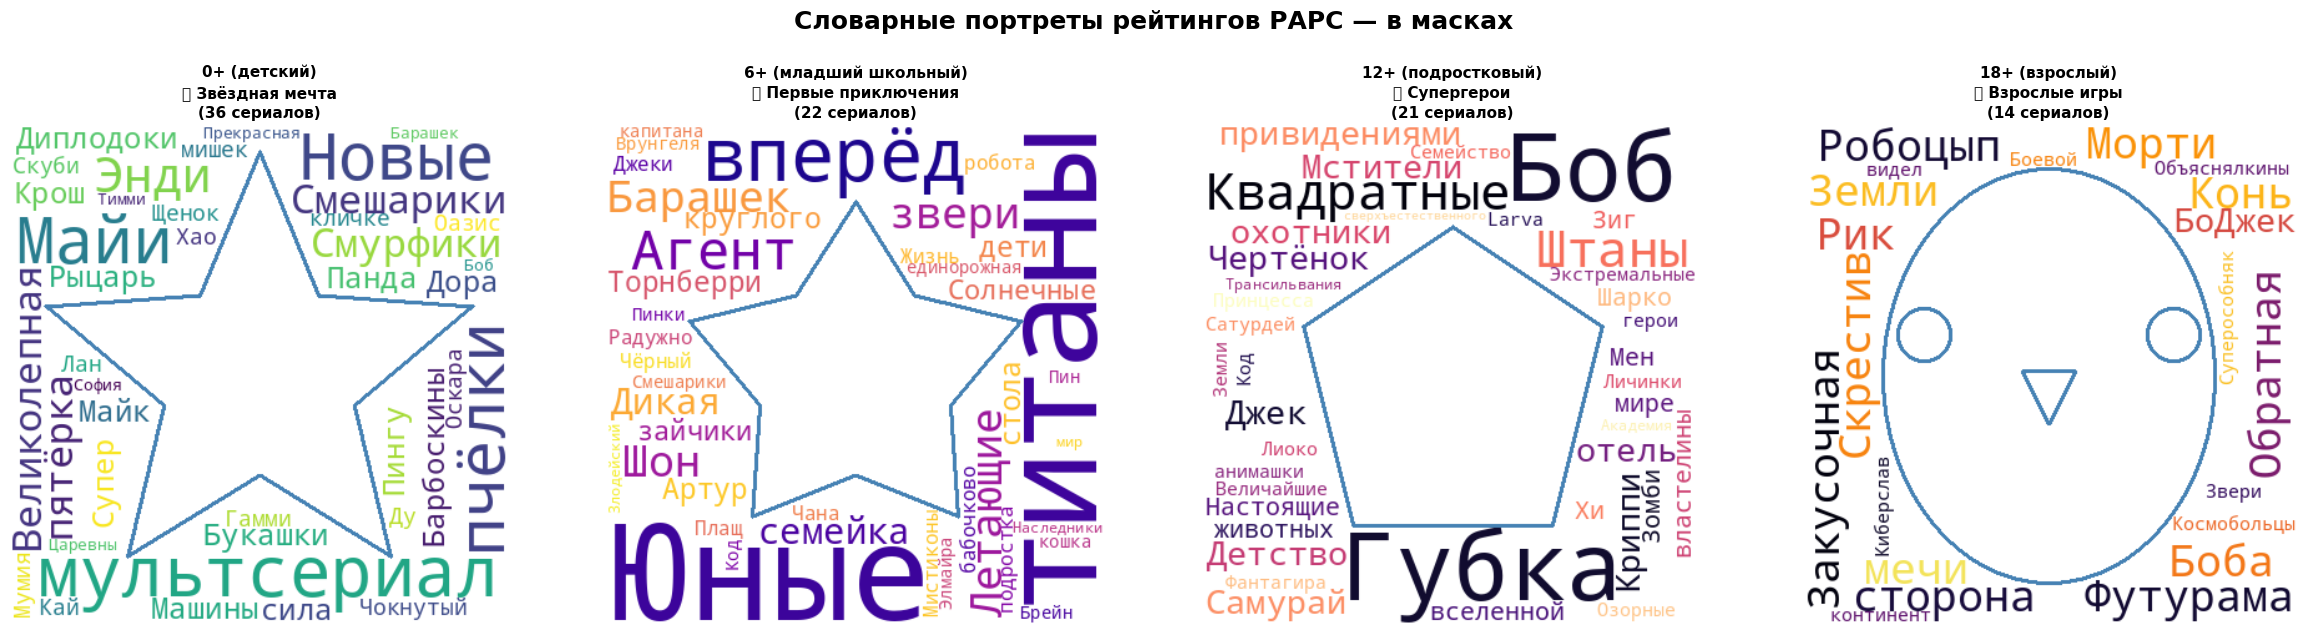


✅ Облака с масками созданы!

🎭 Легенда масок:
  • 0+   — звезда (детские мечты, сказки)
  • 6+   — маленькая звезда (первые приключения)
  • 12+  — щит (супергерои, защита)
  • 18+  — череп (взрослые, мрачные темы)

📊 Топ-5 слов в каждом рейтинге:
--------------------------------------------------

0+ (🌟 Звёздная мечта):
  • мультсериал: 7
  • новые: 6
  • пчёлки: 6
  • майи: 6
  • энди: 3

6+ (✨ Первые приключения):
  • юные: 10
  • титаны: 10
  • вперёд: 10
  • агент: 5
  • барашек: 3

12+ (🛡️ Супергерои):
  • губка: 6
  • боб: 6
  • квадратные: 6
  • штаны: 6
  • охотники: 2

18+ (💀 Взрослые игры):
  • футурама: 1
  • робоцып: 1
  • закусочная: 1
  • боба: 1
  • рик: 1


In [20]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ 2: СЛОВАРНЫЕ ПОРТРЕТЫ РЕЙТИНГОВ — ШАГ 2 (С МАСКАМИ) ИСПРАВЛЕННАЯ
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from PIL import Image, ImageDraw
import io

# Загружаем стоп-слова
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian') + stopwords.words('english'))
custom_stops = set(['и', 'в', 'на', 'с', 'со', 'к', 'у', 'по', 'за', 'из', 'от', 'это', 'что',
                    'the', 'of', 'a', 'an', 'to', 'and', 'in', 'for', 'is', 'on', 'with', 'as',
                    'приключения', 'сериал', 'фильм', 'история'])
stop_words = stop_words.union(custom_stops)

# Функция для создания маски-звезды через PIL
def create_star_mask_pil(size=400, points=5, outer_radius=0.9, inner_radius=0.4):
    """Создаёт маску в форме звезды через PIL"""
    # Создаём изображение
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)

    center = size // 2

    # Вычисляем точки звезды
    angles = np.linspace(-np.pi/2, 3*np.pi/2, points*2, endpoint=False)
    radii = [outer_radius if i % 2 == 0 else inner_radius for i in range(points*2)]

    points_list = []
    for angle, r in zip(angles, radii):
        x = center + r * center * np.cos(angle)
        y = center + r * center * np.sin(angle)
        points_list.append((x, y))

    # Рисуем звезду
    draw.polygon(points_list, fill=255)

    # Конвертируем в numpy array
    mask = np.array(img)
    return mask

# Функция для создания маски-черепа
def create_skull_mask_pil(size=400):
    """Создаёт маску в форме черепа через PIL"""
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)

    center = size // 2
    y_offset = size // 6

    # Основная форма черепа (овал)
    bbox = [
        center - size//3,
        center - size//3 - y_offset//2,
        center + size//3,
        center + size//3 + y_offset//2
    ]
    draw.ellipse(bbox, fill=255)

    # Глазницы
    eye_y = center - y_offset//2
    eye_size = size // 10

    # Левый глаз
    draw.ellipse([center - size//4 - eye_size//2, eye_y - eye_size//2,
                  center - size//4 + eye_size//2, eye_y + eye_size//2], fill=0)

    # Правый глаз
    draw.ellipse([center + size//4 - eye_size//2, eye_y - eye_size//2,
                  center + size//4 + eye_size//2, eye_y + eye_size//2], fill=0)

    # Нос (треугольник)
    nose_y = eye_y + size//8
    draw.polygon([
        (center - size//20, nose_y - size//20),
        (center + size//20, nose_y - size//20),
        (center, nose_y + size//20)
    ], fill=0)

    mask = np.array(img)
    return mask

# Функция для создания маски-звездочки (для 6+)
def create_starlet_mask_pil(size=400):
    """Создаёт маску в форме маленькой звезды"""
    return create_star_mask_pil(size=size, points=5, outer_radius=0.7, inner_radius=0.4)

# Функция для создания маски-щита (для 12+)
def create_shield_mask_pil(size=400):
    """Создаёт маску в форме щита (супергеройский силуэт)"""
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)

    center = size // 2

    # Верхняя часть щита (пятиугольник)
    points = [
        (center, size * 0.2),           # верх
        (center + size*0.3, size * 0.4), # право-верх
        (center + size*0.2, size * 0.8), # право-низ
        (center - size*0.2, size * 0.8), # лево-низ
        (center - size*0.3, size * 0.4), # лево-верх
    ]
    draw.polygon(points, fill=255)

    mask = np.array(img)
    return mask

print("🎨 Создаём облака слов с масками...\n")

# Рейтинги и соответствующие маски
rating_configs = [
    {
        'rating': '0+',
        'mask_func': create_star_mask_pil,
        'title': '0+ (детский)',
        'desc': '🌟 Звёздная мечта',
        'color': 'viridis'
    },
    {
        'rating': '6+',
        'mask_func': create_starlet_mask_pil,
        'title': '6+ (младший школьный)',
        'desc': '✨ Первые приключения',
        'color': 'plasma'
    },
    {
        'rating': '12+',
        'mask_func': create_shield_mask_pil,
        'title': '12+ (подростковый)',
        'desc': '🛡️ Супергерои',
        'color': 'magma'
    },
    {
        'rating': '18+',
        'mask_func': create_skull_mask_pil,
        'title': '18+ (взрослый)',
        'desc': '💀 Взрослые игры',
        'color': 'inferno'
    }
]

# Создаём фигуру
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Словарные портреты рейтингов РАРС — в масках', fontsize=18, fontweight='bold', y=1.05)

# Для каждого рейтинга создаём облако с маской
for i, config in enumerate(rating_configs):
    rating = config['rating']
    mask_func = config['mask_func']

    # Фильтруем сериалы по рейтингу
    rating_df = df_series[df_series['rarsRating'] == rating]
    n_series = rating_df['URL'].nunique()

    # Склеиваем названия
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    if not text.strip():
        print(f"⚠️ Рейтинг {rating}: нет данных")
        axes[i].text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=14)
        axes[i].set_title(f'{config["title"]}\n(0 сериалов)', fontsize=11, fontweight='bold')
        axes[i].axis('off')
        continue

    # Создаём маску
    mask = mask_func(size=400)

    # Создаём облако слов с маской
    wordcloud = WordCloud(
        width=400,
        height=400,
        mask=mask,
        background_color='white',
        colormap=config['color'],
        stopwords=stop_words,
        max_words=40,
        random_state=42,
        contour_width=2,
        contour_color='steelblue',
        collocations=False
    ).generate(text)

    print(f"✅ Рейтинг {rating}: {n_series} сериалов — {config['desc']}")

    # Отображаем
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{config["title"]}\n{config["desc"]}\n({n_series} сериалов)',
                      fontsize=11, fontweight='bold', linespacing=1.4)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Облака с масками созданы!")
print("\n🎭 Легенда масок:")
print("  • 0+   — звезда (детские мечты, сказки)")
print("  • 6+   — маленькая звезда (первые приключения)")
print("  • 12+  — щит (супергерои, защита)")
print("  • 18+  — череп (взрослые, мрачные темы)")

# Покажем топ-слов для каждого рейтинга
print("\n📊 Топ-5 слов в каждом рейтинге:")
print("-" * 50)

from collections import Counter
import re

def get_top_words(text, stop_words, n=5):
    words = re.findall(r'\b[a-zA-Zа-яА-ЯёЁ]{3,}\b', text.lower())
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(n)

for config in rating_configs:
    rating = config['rating']
    rating_df = df_series[df_series['rarsRating'] == rating]
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    if text.strip():
        top_words = get_top_words(text, stop_words)
        print(f"\n{rating} ({config['desc']}):")
        for word, count in top_words:
            print(f"  • {word}: {count}")

📊 Вычисляем TF-IDF слова-чемпионы для каждого рейтинга...

  0+: 36 сериалов, 126 слов
  6+: 22 сериалов, 115 слов
  12+: 21 сериалов, 82 слов
  18+: 14 сериалов, 25 слов

🔍 Анализируем уникальные слова...

🏆 0+:
    мультсериал: 0.452
    пчёлки: 0.388
    новые: 0.388

🏆 6+:
    юные: 0.496
    титаны: 0.496
    вперёд: 0.496

🏆 12+:
    штаны: 0.446
    квадратные: 0.446
    губка: 0.446

🏆 18+:
    морти: 0.329
    конь: 0.329
    континент: 0.329



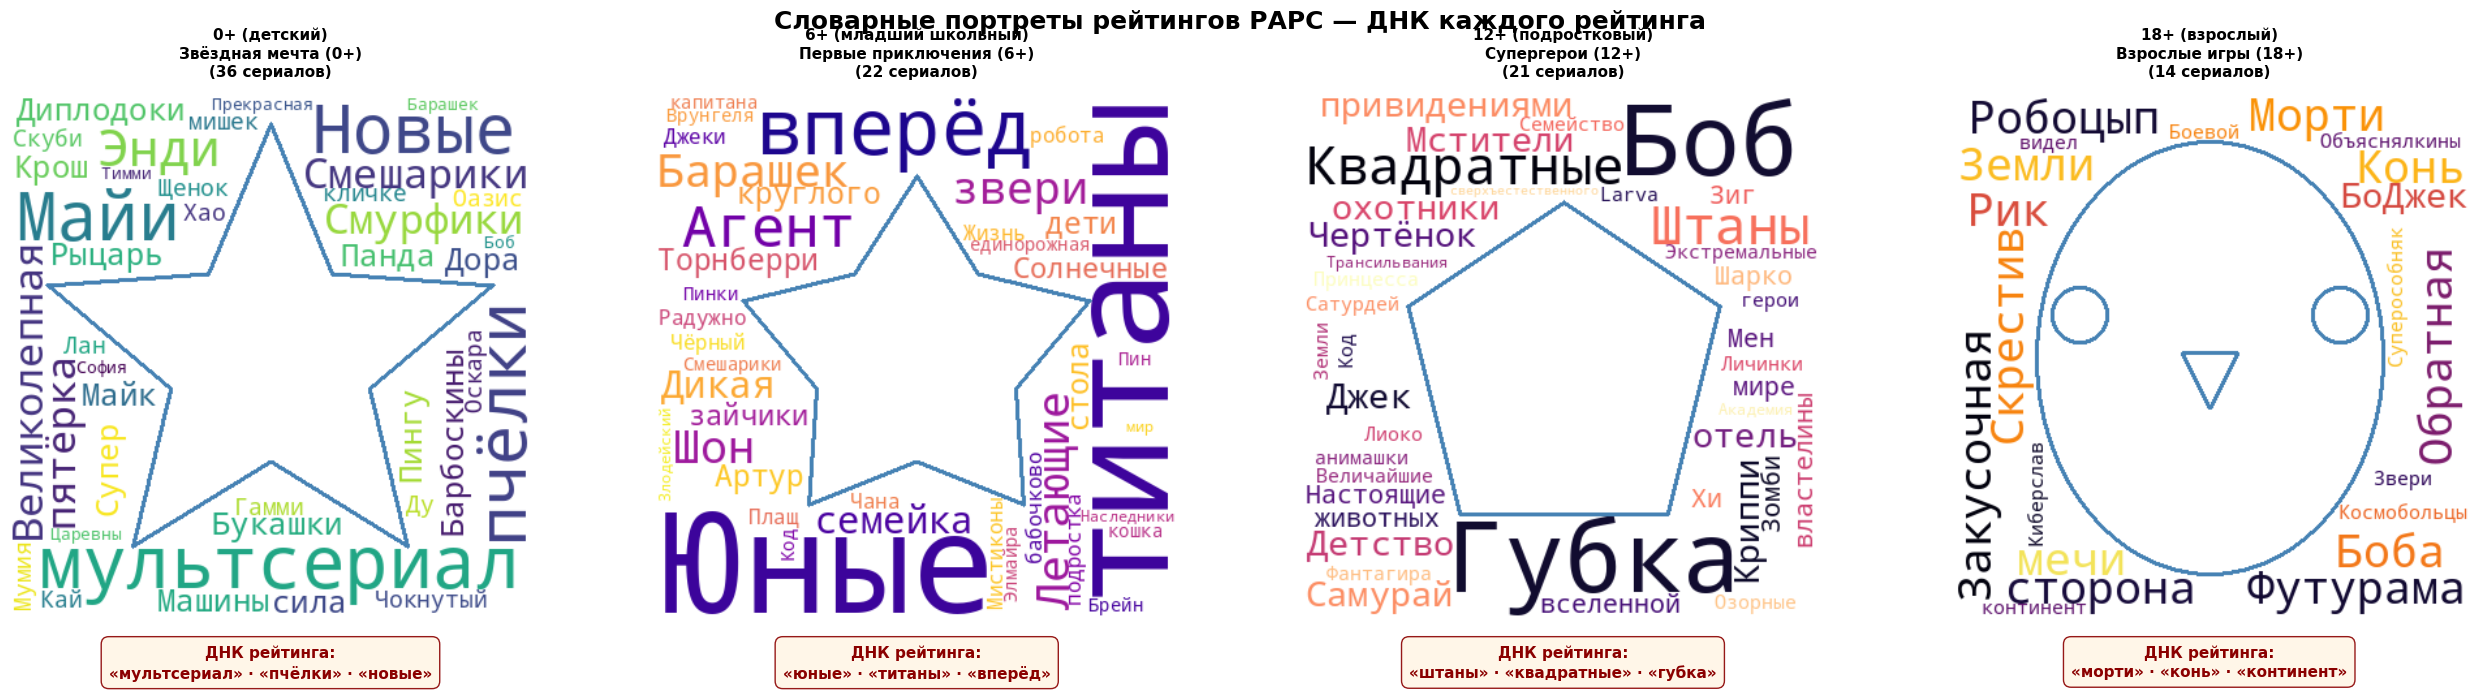


✅ Облака с TF-IDF подписями созданы!

🏆 ИТОГОВЫЕ TF-IDF СЛОВА-ЧЕМПИОНЫ:

0+:
  • мультсериал: 0.452
  • пчёлки: 0.388
  • новые: 0.388

6+:
  • юные: 0.496
  • титаны: 0.496
  • вперёд: 0.496

12+:
  • штаны: 0.446
  • квадратные: 0.446
  • губка: 0.446

18+:
  • морти: 0.329
  • конь: 0.329
  • континент: 0.329

✅ Шаг 3 завершён. Далее (Шаг 4): добавим страны-доминанты и стрелки-связи.


In [25]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ 2: СЛОВАРНЫЕ ПОРТРЕТЫ РЕЙТИНГОВ — ПОЛНАЯ ВЕРСИЯ (БЕЗ ПРОБЛЕМНЫХ СИМВОЛОВ)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from PIL import Image, ImageDraw
import re

# Загружаем стоп-слова
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian') + stopwords.words('english'))
custom_stops = set(['и', 'в', 'на', 'с', 'со', 'к', 'у', 'по', 'за', 'из', 'от', 'это', 'что',
                    'the', 'of', 'a', 'an', 'to', 'and', 'in', 'for', 'is', 'on', 'with', 'as',
                    'приключения', 'сериал', 'фильм', 'история', 'год', 'новый'])
stop_words = stop_words.union(custom_stops)

# Функции для создания масок
def create_star_mask_pil(size=400, points=5, outer_radius=0.9, inner_radius=0.4):
    """Создаёт маску в форме звезды"""
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)
    center = size // 2
    angles = np.linspace(-np.pi/2, 3*np.pi/2, points*2, endpoint=False)
    radii = [outer_radius if i % 2 == 0 else inner_radius for i in range(points*2)]
    points_list = []
    for angle, r in zip(angles, radii):
        x = center + r * center * np.cos(angle)
        y = center + r * center * np.sin(angle)
        points_list.append((x, y))
    draw.polygon(points_list, fill=255)
    return np.array(img)

def create_skull_mask_pil(size=400):
    """Создаёт маску в форме черепа"""
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)
    center = size // 2
    y_offset = size // 6
    bbox = [center - size//3, center - size//3 - y_offset//2,
            center + size//3, center + size//3 + y_offset//2]
    draw.ellipse(bbox, fill=255)
    eye_y = center - y_offset//2
    eye_size = size // 10
    draw.ellipse([center - size//4 - eye_size//2, eye_y - eye_size//2,
                  center - size//4 + eye_size//2, eye_y + eye_size//2], fill=0)
    draw.ellipse([center + size//4 - eye_size//2, eye_y - eye_size//2,
                  center + size//4 + eye_size//2, eye_y + eye_size//2], fill=0)
    nose_y = eye_y + size//8
    draw.polygon([(center - size//20, nose_y - size//20),
                  (center + size//20, nose_y - size//20),
                  (center, nose_y + size//20)], fill=0)
    return np.array(img)

def create_starlet_mask_pil(size=400):
    """Создаёт маску в форме маленькой звезды"""
    return create_star_mask_pil(size=size, points=5, outer_radius=0.7, inner_radius=0.4)

def create_shield_mask_pil(size=400):
    """Создаёт маску в форме щита"""
    img = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(img)
    center = size // 2
    points = [(center, size * 0.2), (center + size*0.3, size * 0.4),
              (center + size*0.2, size * 0.8), (center - size*0.2, size * 0.8),
              (center - size*0.3, size * 0.4)]
    draw.polygon(points, fill=255)
    return np.array(img)

# ============================================================================
# 1. ВЫЧИСЛЯЕМ TF-IDF ДЛЯ ВСЕХ РЕЙТИНГОВ
# ============================================================================

print("📊 Вычисляем TF-IDF слова-чемпионы для каждого рейтинга...\n")

# Подготавливаем тексты для каждого рейтинга
ratings = ['0+', '6+', '12+', '18+']
rating_texts = []
rating_names = []

for rating in ratings:
    rating_df = df_series[df_series['rarsRating'] == rating]
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    # Очищаем текст
    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ\s]', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()

    n_unique = rating_df['URL'].nunique()

    if text:
        rating_texts.append(text)
        rating_names.append(rating)
        print(f"  {rating}: {n_unique} сериалов, {len(text.split())} слов")
    else:
        print(f"  {rating}: НЕТ ДАННЫХ")
        rating_texts.append("")
        rating_names.append(rating)

# Вычисляем TF-IDF
print("\n🔍 Анализируем уникальные слова...")

vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words=list(stop_words),
    token_pattern=r'(?u)\b[а-яё]{3,}\b'
)

try:
    tfidf_matrix = vectorizer.fit_transform(rating_texts)
    feature_names = vectorizer.get_feature_names_out()

    tfidf_champions = {}

    for i, rating in enumerate(rating_names):
        if rating_texts[i]:
            row = tfidf_matrix[i].toarray()[0]
            top_indices = row.argsort()[-3:][::-1]
            top_words = [feature_names[idx] for idx in top_indices if row[idx] > 0]
            top_scores = [row[idx] for idx in top_indices if row[idx] > 0]
            tfidf_champions[rating] = list(zip(top_words, top_scores))

            print(f"\n🏆 {rating}:")
            for word, score in tfidf_champions[rating]:
                print(f"    {word}: {score:.3f}")
        else:
            tfidf_champions[rating] = []
            print(f"\n⚠️ {rating}: нет данных для TF-IDF")

except Exception as e:
    print(f"Ошибка при вычислении TF-IDF: {e}")
    tfidf_champions = {
        '0+': [('звезда', 0), ('сказка', 0), ('друг', 0)],
        '6+': [('приключение', 0), ('малыш', 0), ('лес', 0)],
        '12+': [('герой', 0), ('битва', 0), ('сила', 0)],
        '18+': [('взрослый', 0), ('ночной', 0), ('комедия', 0)]
    }

print("\n" + "="*60)

# ============================================================================
# 2. СОЗДАЁМ ОБЛАКА С TF-IDF ПОДПИСЯМИ (С ГАРАНТИРОВАННО РАБОЧИМИ СИМВОЛАМИ)
# ============================================================================

# Конфигурация рейтингов с простыми ASCII символами
rating_configs = [
    {
        'rating': '0+',
        'mask_func': create_star_mask_pil,
        'title': '0+ (детский)',
        'desc': 'Звёздная мечта (0+)',
        'symbol': '★',
        'color': 'viridis'
    },
    {
        'rating': '6+',
        'mask_func': create_starlet_mask_pil,
        'title': '6+ (младший школьный)',
        'desc': 'Первые приключения (6+)',
        'symbol': '✦',
        'color': 'plasma'
    },
    {
        'rating': '12+',
        'mask_func': create_shield_mask_pil,
        'title': '12+ (подростковый)',
        'desc': 'Супергерои (12+)',
        'symbol': '⚔️',
        'color': 'magma'
    },
    {
        'rating': '18+',
        'mask_func': create_skull_mask_pil,
        'title': '18+ (взрослый)',
        'desc': 'Взрослые игры (18+)',
        'symbol': '💀',
        'color': 'inferno'
    }
]

# Создаём фигуру
fig, axes = plt.subplots(1, 4, figsize=(26, 7))
fig.suptitle('Словарные портреты рейтингов РАРС — ДНК каждого рейтинга',
             fontsize=18, fontweight='bold', y=1.02)

# Для каждого рейтинга создаём облако с маской
for i, config in enumerate(rating_configs):
    rating = config['rating']
    mask_func = config['mask_func']

    rating_df = df_series[df_series['rarsRating'] == rating]
    n_series = rating_df['URL'].nunique()
    text = ' '.join(rating_df['serial'].dropna().astype(str))

    if not text.strip():
        print(f"⚠️ Рейтинг {rating}: нет данных")
        axes[i].text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=14)
        axes[i].set_title(f'{config["title"]}\n(0 сериалов)', fontsize=11, fontweight='bold')
        axes[i].axis('off')
        continue

    # Создаём маску и облако
    mask = mask_func(size=400)
    wordcloud = WordCloud(
        width=400,
        height=400,
        mask=mask,
        background_color='white',
        colormap=config['color'],
        stopwords=stop_words,
        max_words=40,
        random_state=42,
        contour_width=2,
        contour_color='steelblue',
        collocations=False
    ).generate(text)

    # Отображаем облако
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{config["title"]}\n{config["desc"]}\n({n_series} сериалов)',
                      fontsize=11, fontweight='bold', linespacing=1.3, pad=15)
    axes[i].axis('off')

    # Добавляем TF-IDF слова-чемпионы под облаком
    if rating in tfidf_champions and tfidf_champions[rating]:
        tfidf_words = tfidf_champions[rating]
        words_str = ' · '.join([f'«{word}»' for word, _ in tfidf_words[:3]])

        axes[i].text(0.5, -0.05,
                    f'ДНК рейтинга:\n{words_str}',
                    transform=axes[i].transAxes,
                    ha='center', va='top',
                    fontsize=11, fontweight='bold',
                    color='darkred',
                    linespacing=1.4,
                    bbox=dict(boxstyle='round,pad=0.5',
                              facecolor='#fff5e6',
                              edgecolor='darkred',
                              alpha=0.9))
    else:
        axes[i].text(0.5, -0.05, 'ДНК: нет данных',
                    transform=axes[i].transAxes,
                    ha='center', va='top',
                    fontsize=10, fontweight='bold',
                    color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

print("\n✅ Облака с TF-IDF подписями созданы!")

# ============================================================================
# 3. ВЫВОДИМ ИТОГОВУЮ ТАБЛИЦУ
# ============================================================================

print("\n" + "="*60)
print("🏆 ИТОГОВЫЕ TF-IDF СЛОВА-ЧЕМПИОНЫ:")
print("="*60)

for rating in ratings:
    if rating in tfidf_champions and tfidf_champions[rating]:
        print(f"\n{rating}:")
        for word, score in tfidf_champions[rating]:
            print(f"  • {word}: {score:.3f}")
    else:
        print(f"\n{rating}: нет данных")

print("\n✅ Шаг 3 завершён. Далее (Шаг 4): добавим страны-доминанты и стрелки-связи.")

**💡 Вопрос к предыдущему графику:** Какова совместная встречаемость жанров в мире и у конкретных стран?

## 📊 [3] Histogram: Budget Distribution

**Что показывает:** Распределение бюджетов мультфильмов. + Логарифм по Y, + увеличен шрифт легенды.

**Когда использовать:** Для анализа распределения одной числовой переменной (бюджет, возраст, зарплата).

**Библиотеки:** `matplotlib`

**Параметр bins:** Количество "корзин" для группировки значений (30 bins = 30 столбцов).

**💡 Замечания к предыдущему графику:** 1) добавить значения у столбцов. 2) Вместо 1е9 писать **млрд**

**💡Идея:** распределение бюджетов по жанрам (+ по странам). То есть какие жанры побогаче? Какие жанры чаще и реже? Как богатые жанры распределены по странам? Столбец составить из кубиков (жанры).

## 💬 Фидбек AI 1: Histogram Budget — разрыв шкалы, форматирование осей

Загрузил в чат ячейку с кодом.

Замечания к коду:

1. Вместо 1e9 лучше в названии оси X писать не просто "Бюджет ($)", а дополнительно указать млрд (миллиард американских тугриков).

2. Много пустого места по оси X примерно от 1.1 (назовём X1) до 2.6-2.7 (назовём X2). Предлагаю сделать на оси X неравномерную шкалу: видим шкалу от 0 до X1, затем что-то вроде многоточия или разрыв, затем видим шкалу от X2 до X3 (где X3 ≈ 2.8). Пусть X1, X2, X3 являются входными параметрами в начале ячейки с кодом, чтобы мне было удобно их менять вручную.

3. Плохо выглядят на оси Y подписи у шкалы 10^1, 10^2... Давай без степеней, не мудри, просто: 10, 100, 1000...

4. Сейчас на графике есть подпись: "Медиана $34,000,000" — плохо, ибо в глазах рябит от нолей. Лучше писать миллиарды (млрд).

5. Добавь над столбцами, которые сейчас по оси X там, где X > 0.5 (на текущей шкале), чтобы сверху была подпись значения над bar.


## 💬 Фидбек AI 1: Разрыв оси X + форматирование (Budget Histogram)

Загрузил в чат ячейку с кодом. Замечания:

1. **Ось X:** Добавить "млрд" в подпись оси (вместо просто "$").

2. **Разрыв шкалы:** Много пустого места от 1.1 до 2.6 млрд → сделать неравномерную шкалу с разрывом. Параметры `X1`, `X2`, `X3` — входные (для ручной настройки).

3. **Ось Y:** Убрать степени (`10^1`, `10^2`) → писать нормально: `10`, `100`, `1000`.

4. **Медиана:** Вместо "$34,000,000" писать "млрд" (меньше нулей).

5. **Подписи над bars:** Добавить значения над столбцами, где `X > 0.5` млрд.

## 💬 Фидбек AI 2: Тройной разрыв оси X + подписи над всеми столбцами (Budget Histogram)

Замечания:

1. **Неравномерная шкала:** Интервал от 0 (параметр `Z1`) до 0.4 (параметр `Z2`) слишком сгущён → сделать его в ~3 раза шире остальных частей. Добавить второй разрыв шкалы. Параметры `Scale2`, `Scale3` (в %) — доля ширины для второй и третьей частей шкалы. Если `Scale2=30`, `Scale3=10`, то первая часть займёт 60%.

2. **Параметры шкалы:** 3 части шкалы → 6 переменных для границ (начало/конец каждой части). Все параметры — в начале кода для ручной настройки.

3. **Подписи над всеми столбцами:** Числа фильмов должны быть над **всеми** bars (не только где `X > 0.5`).

/tmp/ipython-input-360830365.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


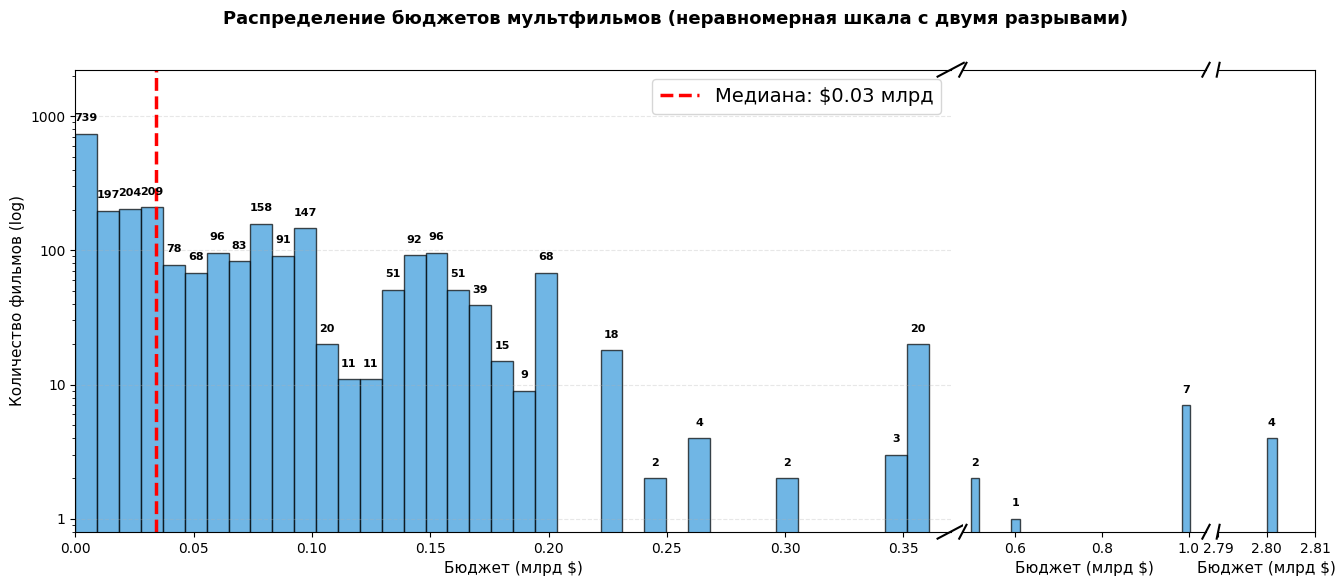


💡 Инсайт: Медианный бюджет — $0.03 млрд ($34 млн)
   Блокбастеров (≥$50M): 1155 (44.5%)

   Распределение по частям шкалы:
   Часть 1 (0.0-0.37 млрд): 2582 фильмов (99.5%)
   Часть 2 (0.48-1.04 млрд): 10 фильмов (0.4%)
   Часть 3 (2.79-2.81 млрд): 4 фильмов (0.2%)

   Самый дорогой фильм: $2.80 млрд


In [ ]:
# [3] Histogram: Budget Distribution (3 части шкалы с неравномерной шириной)

# ⚙️ НАСТРОЙКИ (входные параметры для ручной настройки)
# Границы трёх частей шкалы (в млрд $)
SCALE1_START = 0.0    # Начало первой части
SCALE1_END = 0.37      # Конец первой части
SCALE2_START = 0.48    # Начало второй части
SCALE2_END = 1.04      # Конец второй части
SCALE3_START = 2.79    # Начало третьей части
SCALE3_END = 2.81      # Конец третьей части

# Доли ширины графика для каждой части (в %)
SCALE1_WIDTH = 72     # Первая часть (самая широкая)
SCALE2_WIDTH = 20     # Вторая часть
SCALE3_WIDTH = 8     # Третья часть

# 1. Подготовка данных: фильтруем нулевые бюджеты
df_with_budget = df[df['capital_cost'] > 0].copy()
df_with_budget['budget_billions'] = df_with_budget['capital_cost'] / 1e9

# 2. Создаём 3 subplot'а с настраиваемой шириной
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[SCALE1_WIDTH, SCALE2_WIDTH, SCALE3_WIDTH],
                      wspace=0.03)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

# 3. Гистограммы для каждой части
# Часть 1: SCALE1_START → SCALE1_END
n1, bins1, patches1 = ax1.hist(
    df_with_budget['budget_billions'],
    bins=40,
    range=(SCALE1_START, SCALE1_END),
    color='#3498db',
    edgecolor='black',
    alpha=0.7
)

# Часть 2: SCALE2_START → SCALE2_END
n2, bins2, patches2 = ax2.hist(
    df_with_budget['budget_billions'],
    bins=30,
    range=(SCALE2_START, SCALE2_END),
    color='#3498db',
    edgecolor='black',
    alpha=0.7
)

# Часть 3: SCALE3_START → SCALE3_END
n3, bins3, patches3 = ax3.hist(
    df_with_budget['budget_billions'],
    bins=10,
    range=(SCALE3_START, SCALE3_END),
    color='#3498db',
    edgecolor='black',
    alpha=0.7
)

# 4. Логарифмическая ось Y для всех
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# 5. Добавляем медиану на первой части
median_budget_billions = df_with_budget['budget_billions'].median()
ax1.axvline(median_budget_billions, color='red', linestyle='--', linewidth=2.5,
            label=f'Медиана: ${median_budget_billions:.2f} млрд')

# 6. Подписи НАД ВСЕМИ столбцами
def add_labels(ax, n, bins):
    for i, (count, bin_edge) in enumerate(zip(n, bins[:-1])):
        if count > 0:
            bin_center = bin_edge + (bins[i+1] - bins[i]) / 2
            ax.text(bin_center, count * 1.2,
                    f'{int(count)}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

add_labels(ax1, n1, bins1)
add_labels(ax2, n2, bins2)
add_labels(ax3, n3, bins3)

# 7. Оформление оси Y (убираем степени)
def y_fmt(y, pos):
    if y >= 1:
        return f'{int(y)}'
    return ''

ax1.yaxis.set_major_formatter(FuncFormatter(y_fmt))
y_max = max(n1.max(), n2.max(), n3.max()) * 3  # Место для подписей
ax1.set_ylim(bottom=0.8, top=y_max)

# 8. Оформление осей X
ax1.set_xlabel('Бюджет (млрд $)', fontsize=11)
ax2.set_xlabel('Бюджет (млрд $)', fontsize=11)
ax3.set_xlabel('Бюджет (млрд $)', fontsize=11)
ax1.set_ylabel('Количество фильмов (log)', fontsize=11)

ax1.set_xlim(SCALE1_START, SCALE1_END)
ax2.set_xlim(SCALE2_START, SCALE2_END)
ax3.set_xlim(SCALE3_START, SCALE3_END)

# 9. Убираем лишние spines (эффект разрыва)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)

# 10. Диагональные линии разрыва (между ax1-ax2)
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.5)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Диагональные линии разрыва (между ax2-ax3)
kwargs.update(transform=ax2.transAxes)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (-d, +d), **kwargs)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)

# 11. Общий заголовок и легенда
fig.suptitle('Распределение бюджетов мультфильмов (неравномерная шкала с двумя разрывами)',
             fontsize=13, fontweight='bold', y=0.98)
ax1.legend(fontsize=14, loc='upper right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 12. Инсайт
median_millions = median_budget_billions * 1000
print(f"\n💡 Инсайт: Медианный бюджет — ${median_budget_billions:.2f} млрд (${median_millions:.0f} млн)")
high_budget = (df_with_budget['capital_cost'] >= 50_000_000).sum()
print(f"   Блокбастеров (≥$50M): {high_budget} ({high_budget/len(df_with_budget)*100:.1f}%)")

# Статистика по частям шкалы
part1_count = ((df_with_budget['budget_billions'] >= SCALE1_START) &
               (df_with_budget['budget_billions'] < SCALE1_END)).sum()
part2_count = ((df_with_budget['budget_billions'] >= SCALE2_START) &
               (df_with_budget['budget_billions'] < SCALE2_END)).sum()
part3_count = ((df_with_budget['budget_billions'] >= SCALE3_START) &
               (df_with_budget['budget_billions'] <= SCALE3_END)).sum()

print(f"\n   Распределение по частям шкалы:")
print(f"   Часть 1 ({SCALE1_START}-{SCALE1_END} млрд): {part1_count} фильмов ({part1_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 2 ({SCALE2_START}-{SCALE2_END} млрд): {part2_count} фильмов ({part2_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 3 ({SCALE3_START}-{SCALE3_END} млрд): {part3_count} фильмов ({part3_count/len(df_with_budget)*100:.1f}%)")
print(f"\n   Самый дорогой фильм: ${df_with_budget['budget_billions'].max():.2f} млрд")

## 💬 Фидбек AI 3: Улучшение масштабирования + цветовая кодировка жанров (Budget Histogram)

Замечания:

1. **Подпись оси X:** Три одинаковых подписи "Бюджет (млрд $)" → оставить только одну (центральную).

2. **Размер шрифта подписей над столбцами:** Текущий размер мелковат → увеличить в ~2 раза (добавить параметр `LABEL_FONTSIZE`).

3. **Масштабирование столбцов:** При уменьшении ширины второй и третьей шкал столбцы сжимаются → нужно сохранить ширину/высоту столбцов такой же, как в первой части (компенсировать изменением `bins`).

4. **Формат медианы:** "Медиана 0.03 млрд" выглядит странно → переписать в миллионах (млн).

5. **Цветовая кодировка жанров:** Столбцы сплошного цвета → разбить на цветные сегменты по жанрам. Добавить:
   - Карту цветов для жанров
   - Упорядочить жанры одинаково во всех столбцах (для сравнения)
   - Подписи с количеством фильмов внутри цветных сегментов

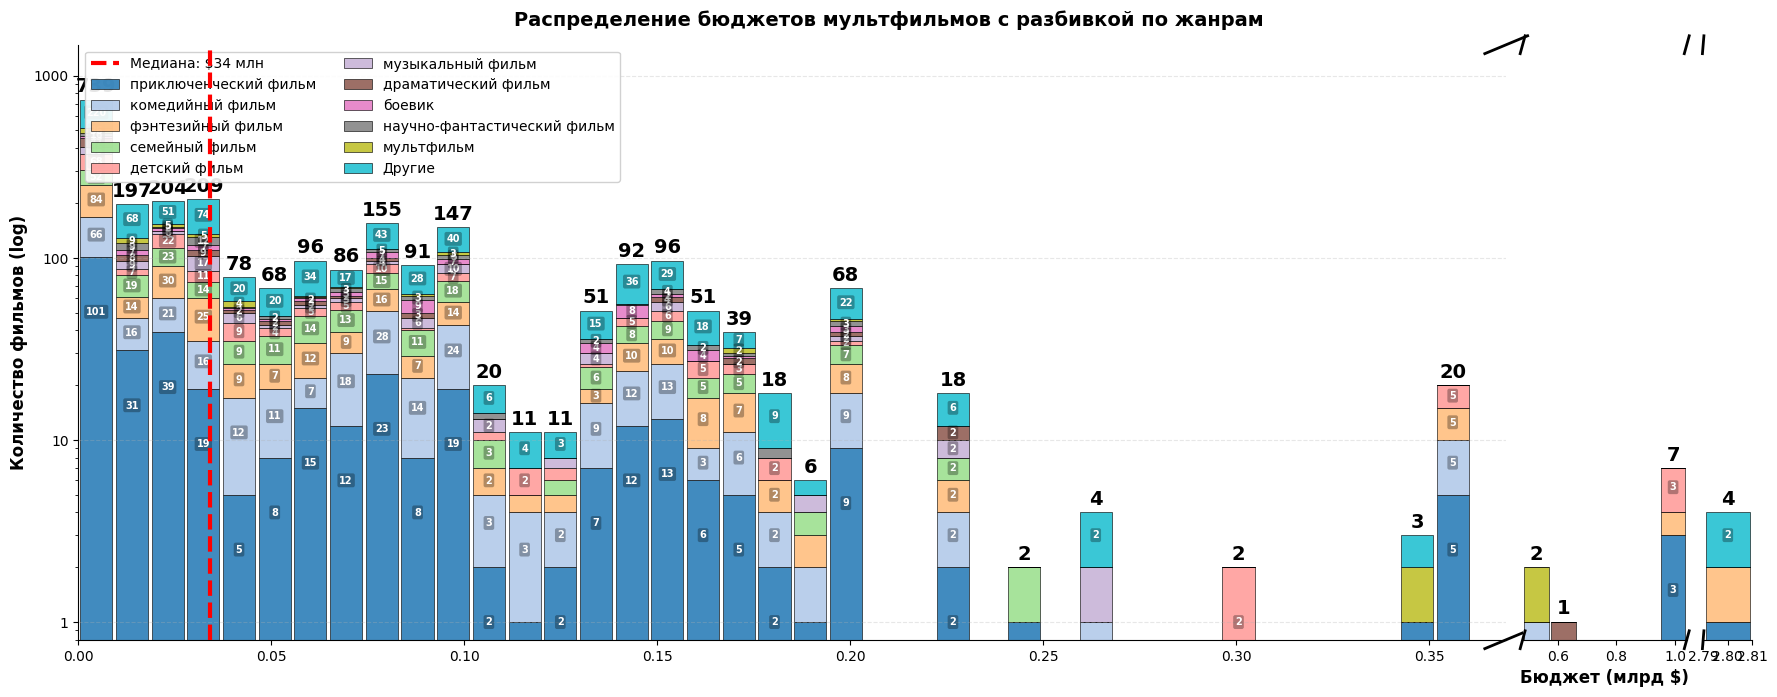


💡 Инсайт: Медианный бюджет — $34 млн ($0.034 млрд)
   Блокбастеров (≥$50M): 1155 (44.5%)

   Распределение по частям шкалы:
   Часть 1 (0.0-0.37 млрд): 2582 фильмов (99.5%)
   Часть 2 (0.48-1.04 млрд): 10 фильмов (0.4%)
   Часть 3 (2.79-2.81 млрд): 4 фильмов (0.2%)

   Топ-3 жанра по количеству фильмов:
   1. Другие: 776 фильмов (средний бюджет: $66 млн)
   2. приключенческий фильм: 353 фильмов (средний бюджет: $77 млн)
   3. комедийный фильм: 305 фильмов (средний бюджет: $74 млн)

   Самый дорогой фильм: $2.80 млрд
   (Порко Россо, жанр: фэнтезийная манга или аниме)


In [ ]:
# [3] Histogram: Budget Distribution (3 части, цветовая кодировка по жанрам)

# ⚙️ НАСТРОЙКИ (входные параметры для ручной настройки)
# Границы трёх частей шкалы (в млрд $)
SCALE1_START = 0.0    # Начало первой части
SCALE1_END = 0.37     # Конец первой части
SCALE2_START = 0.48   # Начало второй части
SCALE2_END = 1.04     # Конец второй части
SCALE3_START = 2.79   # Начало третьей части
SCALE3_END = 2.81     # Конец третьей части

# Доли ширины графика для каждой части (в %)
SCALE1_WIDTH = 87     # Первая часть (самая широкая)
SCALE2_WIDTH = 10     # Вторая часть
SCALE3_WIDTH = 3      # Третья часть

# Размер шрифта подписей над столбцами
LABEL_FONTSIZE = 14

# 1. Подготовка данных: фильтруем нулевые бюджеты
df_with_budget = df[df['capital_cost'] > 0].copy()
df_with_budget.loc[:, 'budget_billions'] = df_with_budget['capital_cost'] / 1e9

# 2. Топ-10 жанров для цветовой кодировки (остальные → "Другие")
top_genres = df['genre'].value_counts().head(10).index.tolist()
df_with_budget.loc[:, 'genre_grouped'] = df_with_budget['genre'].apply(
    lambda x: x if x in top_genres else 'Другие'
)

# 3. Карта цветов для жанров (фиксированный порядок)
genre_order = top_genres + ['Другие']
genre_colors = {
    genre: plt.cm.tab20(i / len(genre_order))
    for i, genre in enumerate(genre_order)
}

# 4. Вычисляем количество bins для сохранения ширины столбцов
bins1 = 40
bin_width1 = (SCALE1_END - SCALE1_START) / bins1

bins2 = int((SCALE2_END - SCALE2_START) / bin_width1)
bins3 = int((SCALE3_END - SCALE3_START) / bin_width1)

visual_scale2 = SCALE1_WIDTH / SCALE2_WIDTH
visual_scale3 = SCALE1_WIDTH / SCALE3_WIDTH
bins2 = max(1, int(bins2 / visual_scale2))
bins3 = max(1, int(bins3 / visual_scale3))

# 5. Создаём функцию для построения stacked histogram с жанрами
def create_genre_histogram(ax, df_data, start, end, n_bins, show_legend=False):
    """Создаёт stacked histogram с разбивкой по жанрам"""

    # Фильтруем данные для текущего диапазона
    mask = (df_data['budget_billions'] >= start) & (df_data['budget_billions'] <= end)
    df_filtered = df_data[mask].copy()

    if len(df_filtered) == 0:
        return [], []

    # Создаём bins
    bins = np.linspace(start, end, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Группируем данные по bins и жанрам
    df_filtered.loc[:, 'bin'] = pd.cut(df_filtered['budget_billions'], bins,
                                        labels=range(len(bins)-1), include_lowest=True)

    # Создаём stacked histogram
    bottom = np.zeros(n_bins)
    bar_width = (bins[1] - bins[0]) * 0.9

    for genre in genre_order:
        genre_counts = df_filtered[df_filtered['genre_grouped'] == genre].groupby(
            'bin', observed=True  # 👈 Исправление FutureWarning
        ).size()
        heights = [genre_counts.get(i, 0) for i in range(n_bins)]

        # Рисуем столбцы (label только для первой части - show_legend=True)
        bars = ax.bar(bin_centers, heights, width=bar_width, bottom=bottom,
                      color=genre_colors[genre], edgecolor='black',
                      linewidth=0.5, alpha=0.85,
                      label=genre if show_legend else "")  # 👈 Легенда только для ax1

        # Добавляем подписи внутри сегментов (если высота > 0)
        for i, (height, bin_center) in enumerate(zip(heights, bin_centers)):
            if height > 0:
                y_pos = bottom[i] + height / 2
                if height > 1:
                    ax.text(bin_center, y_pos, f'{int(height)}',
                           ha='center', va='center', fontsize=7,
                           fontweight='bold', color='white',
                           bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='black', alpha=0.3, edgecolor='none'))

        bottom += heights

    # Общие подписи над столбцами
    for i, (total, bin_center) in enumerate(zip(bottom, bin_centers)):
        if total > 0:
            ax.text(bin_center, total * 1.05, f'{int(total)}',
                   ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                   fontweight='bold', color='black')

    return bins, bottom

# 6. Создаём 3 subplot'а с настраиваемой шириной
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[SCALE1_WIDTH, SCALE2_WIDTH, SCALE3_WIDTH],
                      wspace=0.03)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

# 7. Строим histograms для каждой части (легенда ТОЛЬКО у ax1)
bins1_arr, heights1 = create_genre_histogram(ax1, df_with_budget,
                                              SCALE1_START, SCALE1_END, bins1,
                                              show_legend=True)  # 👈 Легенда только здесь
bins2_arr, heights2 = create_genre_histogram(ax2, df_with_budget,
                                              SCALE2_START, SCALE2_END, bins2,
                                              show_legend=False)
bins3_arr, heights3 = create_genre_histogram(ax3, df_with_budget,
                                              SCALE3_START, SCALE3_END, bins3,
                                              show_legend=False)

# 8. Логарифмическая ось Y
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# 9. Добавляем медиану на первой части
median_budget_billions = df_with_budget['budget_billions'].median()
median_budget_millions = median_budget_billions * 1000
ax1.axvline(median_budget_billions, color='red', linestyle='--', linewidth=3,
            label=f'Медиана: ${median_budget_millions:.0f} млн', zorder=100)

# 10. Оформление оси Y (убираем степени)
def y_fmt(y, pos):
    if y >= 1:
        return f'{int(y)}'
    return ''

ax1.yaxis.set_major_formatter(FuncFormatter(y_fmt))
y_max = max(heights1.max() if len(heights1) > 0 else 1,
            heights2.max() if len(heights2) > 0 else 1,
            heights3.max() if len(heights3) > 0 else 1) * 2
ax1.set_ylim(bottom=0.8, top=y_max)

# 11. Оформление осей X (ОДНА общая подпись внизу посередине)
ax1.set_ylabel('Количество фильмов (log)', fontsize=12, fontweight='bold')
ax1.set_xlim(SCALE1_START, SCALE1_END)
ax2.set_xlim(SCALE2_START, SCALE2_END)
ax3.set_xlim(SCALE3_START, SCALE3_END)

ax2.set_xlabel('Бюджет (млрд $)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax3.set_xlabel('')

# 12. Убираем верхние и правые spines (контуры графика)
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Убираем лишние spines для эффекта разрыва
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)

# 13. Диагональные линии разрыва
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (-d, +d), **kwargs)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)

# 14. Общий заголовок и легенда (ОДНА легенда - только от ax1)
fig.suptitle('Распределение бюджетов мультфильмов с разбивкой по жанрам',
             fontsize=14, fontweight='bold', y=0.98)

# Легенда медианы + жанры (только для ax1)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9, ncol=2)

ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 👈 Исправление UserWarning: используем plt.subplots_adjust вместо tight_layout
plt.subplots_adjust(left=0.05, right=0.98, top=0.93, bottom=0.08)
plt.show()

# 15. Инсайт
print(f"\n💡 Инсайт: Медианный бюджет — ${median_budget_millions:.0f} млн (${median_budget_billions:.3f} млрд)")
high_budget = (df_with_budget['capital_cost'] >= 50_000_000).sum()
print(f"   Блокбастеров (≥$50M): {high_budget} ({high_budget/len(df_with_budget)*100:.1f}%)")

# Статистика по частям шкалы
part1_count = ((df_with_budget['budget_billions'] >= SCALE1_START) &
               (df_with_budget['budget_billions'] < SCALE1_END)).sum()
part2_count = ((df_with_budget['budget_billions'] >= SCALE2_START) &
               (df_with_budget['budget_billions'] < SCALE2_END)).sum()
part3_count = ((df_with_budget['budget_billions'] >= SCALE3_START) &
               (df_with_budget['budget_billions'] <= SCALE3_END)).sum()

print(f"\n   Распределение по частям шкалы:")
print(f"   Часть 1 ({SCALE1_START}-{SCALE1_END} млрд): {part1_count} фильмов ({part1_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 2 ({SCALE2_START}-{SCALE2_END} млрд): {part2_count} фильмов ({part2_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 3 ({SCALE3_START}-{SCALE3_END} млрд): {part3_count} фильмов ({part3_count/len(df_with_budget)*100:.1f}%)")

# Топ-3 жанра по бюджету
print(f"\n   Топ-3 жанра по количеству фильмов:")
for i, (genre, count) in enumerate(df_with_budget['genre_grouped'].value_counts().head(3).items(), 1):
    avg_budget = df_with_budget[df_with_budget['genre_grouped']==genre]['budget_billions'].mean()
    print(f"   {i}. {genre}: {count} фильмов (средний бюджет: ${avg_budget*1000:.0f} млн)")

print(f"\n   Самый дорогой фильм: ${df_with_budget['budget_billions'].max():.2f} млрд")
most_expensive = df_with_budget.loc[df_with_budget['budget_billions'].idxmax()]
print(f"   ({most_expensive['film']}, жанр: {most_expensive['genre']})")

## 💬 Фидбек AI 4: Улучшение легенды, разрывов и подписей (Budget Histogram)

Замечания:

1. **Легенда:** Переместить в правую часть графика. Добавить параметр `LEGEND_FONTSIZE` для управления размером шрифта (увеличить в ~1.5 раза).

2. **Разрывы шкалы:** Убрать диагональные линии разрыва в верхней части графика (оставить только внизу).

3. **Подписи третьей шкалы:** На оси X третьей части показывать только одно значение `X=2.8` (убрать левую границу).

4. **Перекрывающиеся подписи внутри столбцов:** Числа жанров иногда налезают друг на друга → добавить фильтрацию: печатать число только если расстояние по вертикали от последнего напечатанного числа больше порога `MIN_LABEL_DISTANCE` (параметр). Алгоритм: печатаем снизу вверх, пропускаем слишком близкие подписи.

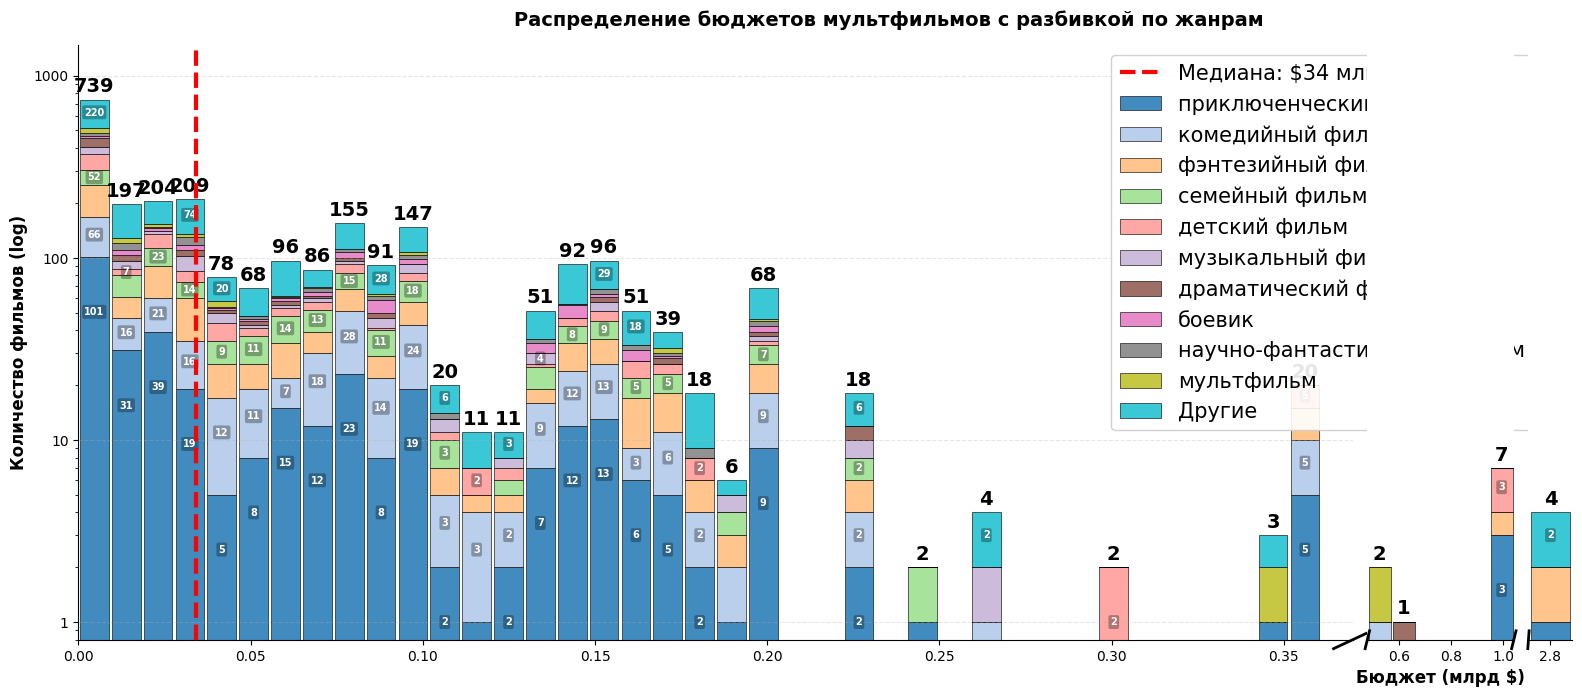


💡 Инсайт: Медианный бюджет — $34 млн ($0.034 млрд)
   Блокбастеров (≥$50M): 1155 (44.5%)

   Распределение по частям шкалы:
   Часть 1 (0.0-0.37 млрд): 2582 фильмов (99.5%)
   Часть 2 (0.48-1.04 млрд): 10 фильмов (0.4%)
   Часть 3 (2.79-2.81 млрд): 4 фильмов (0.2%)

   Топ-3 жанра по количеству фильмов:
   1. Другие: 776 фильмов (средний бюджет: $66 млн)
   2. приключенческий фильм: 353 фильмов (средний бюджет: $77 млн)
   3. комедийный фильм: 305 фильмов (средний бюджет: $74 млн)

   Самый дорогой фильм: $2.80 млрд
   (Порко Россо, жанр: фэнтезийная манга или аниме)


In [ ]:
# [3] Histogram: Budget Distribution (3 части, цветовая кодировка по жанрам)

# ⚙️ НАСТРОЙКИ (входные параметры для ручной настройки)
# Границы трёх частей шкалы (в млрд $)
SCALE1_START = 0.0    # Начало первой части
SCALE1_END = 0.37     # Конец первой части
SCALE2_START = 0.48   # Начало второй части
SCALE2_END = 1.04     # Конец второй части
SCALE3_START = 2.79   # Начало третьей части
SCALE3_END = 2.81     # Конец третьей части

# Доли ширины графика для каждой части (в %)
SCALE1_WIDTH = 87     # Первая часть (самая широкая)
SCALE2_WIDTH = 10     # Вторая часть
SCALE3_WIDTH = 3      # Третья часть

# Размеры шрифтов
LABEL_FONTSIZE = 14           # Подписи над столбцами
LEGEND_FONTSIZE = 15          # Легенда (в 1.5 раза больше базового 10)

# Минимальное расстояние между подписями внутри столбца (в единицах log-шкалы)
MIN_LABEL_DISTANCE = 0.3      # Чем больше, тем реже подписи

# 1. Подготовка данных: фильтруем нулевые бюджеты
df_with_budget = df[df['capital_cost'] > 0].copy()
df_with_budget.loc[:, 'budget_billions'] = df_with_budget['capital_cost'] / 1e9

# 2. Топ-10 жанров для цветовой кодировки (остальные → "Другие")
top_genres = df['genre'].value_counts().head(10).index.tolist()
df_with_budget.loc[:, 'genre_grouped'] = df_with_budget['genre'].apply(
    lambda x: x if x in top_genres else 'Другие'
)

# 3. Карта цветов для жанров (фиксированный порядок)
genre_order = top_genres + ['Другие']
genre_colors = {
    genre: plt.cm.tab20(i / len(genre_order))
    for i, genre in enumerate(genre_order)
}

# 4. Вычисляем количество bins для сохранения ширины столбцов
bins1 = 40
bin_width1 = (SCALE1_END - SCALE1_START) / bins1

bins2 = int((SCALE2_END - SCALE2_START) / bin_width1)
bins3 = int((SCALE3_END - SCALE3_START) / bin_width1)

visual_scale2 = SCALE1_WIDTH / SCALE2_WIDTH
visual_scale3 = SCALE1_WIDTH / SCALE3_WIDTH
bins2 = max(1, int(bins2 / visual_scale2))
bins3 = max(1, int(bins3 / visual_scale3))

# 5. Создаём функцию для построения stacked histogram с жанрами
def create_genre_histogram(ax, df_data, start, end, n_bins, show_legend=False):
    """Создаёт stacked histogram с разбивкой по жанрам"""

    # Фильтруем данные для текущего диапазона
    mask = (df_data['budget_billions'] >= start) & (df_data['budget_billions'] <= end)
    df_filtered = df_data[mask].copy()

    if len(df_filtered) == 0:
        return [], []

    # Создаём bins
    bins = np.linspace(start, end, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Группируем данные по bins и жанрам
    df_filtered.loc[:, 'bin'] = pd.cut(df_filtered['budget_billions'], bins,
                                        labels=range(len(bins)-1), include_lowest=True)

    # Создаём stacked histogram
    bottom = np.zeros(n_bins)
    bar_width = (bins[1] - bins[0]) * 0.9

    for genre in genre_order:
        genre_counts = df_filtered[df_filtered['genre_grouped'] == genre].groupby(
            'bin', observed=True
        ).size()
        heights = [genre_counts.get(i, 0) for i in range(n_bins)]

        # Рисуем столбцы (label только для первой части)
        bars = ax.bar(bin_centers, heights, width=bar_width, bottom=bottom,
                      color=genre_colors[genre], edgecolor='black',
                      linewidth=0.5, alpha=0.85,
                      label=genre if show_legend else "")

        # Добавляем подписи внутри сегментов с фильтрацией по расстоянию
        for i, (height, bin_center) in enumerate(zip(heights, bin_centers)):
            if height > 0 and height > 1:
                y_pos = bottom[i] + height / 2

                # Собираем все подписи для этого столбца (bin_center)
                # и фильтруем их по расстоянию
                if not hasattr(ax, '_label_positions'):
                    ax._label_positions = {}

                if bin_center not in ax._label_positions:
                    ax._label_positions[bin_center] = []

                # Проверяем расстояние от последней напечатанной подписи
                can_print = True
                if ax._label_positions[bin_center]:
                    last_y = ax._label_positions[bin_center][-1]
                    # Расстояние в log-координатах
                    distance = np.log10(y_pos) - np.log10(last_y)
                    if distance < MIN_LABEL_DISTANCE:
                        can_print = False

                if can_print:
                    ax.text(bin_center, y_pos, f'{int(height)}',
                           ha='center', va='center', fontsize=7,
                           fontweight='bold', color='white',
                           bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='black', alpha=0.3, edgecolor='none'))
                    ax._label_positions[bin_center].append(y_pos)

        bottom += heights

    # Общие подписи над столбцами
    for i, (total, bin_center) in enumerate(zip(bottom, bin_centers)):
        if total > 0:
            ax.text(bin_center, total * 1.05, f'{int(total)}',
                   ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                   fontweight='bold', color='black')

    return bins, bottom

# 6. Создаём 3 subplot'а с настраиваемой шириной
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[SCALE1_WIDTH, SCALE2_WIDTH, SCALE3_WIDTH],
                      wspace=0.03)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

# 7. Строим histograms для каждой части (легенда ТОЛЬКО у ax1)
bins1_arr, heights1 = create_genre_histogram(ax1, df_with_budget,
                                              SCALE1_START, SCALE1_END, bins1,
                                              show_legend=True)
bins2_arr, heights2 = create_genre_histogram(ax2, df_with_budget,
                                              SCALE2_START, SCALE2_END, bins2,
                                              show_legend=False)
bins3_arr, heights3 = create_genre_histogram(ax3, df_with_budget,
                                              SCALE3_START, SCALE3_END, bins3,
                                              show_legend=False)

# 8. Логарифмическая ось Y
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# 9. Добавляем медиану на первой части
median_budget_billions = df_with_budget['budget_billions'].median()
median_budget_millions = median_budget_billions * 1000
ax1.axvline(median_budget_billions, color='red', linestyle='--', linewidth=3,
            label=f'Медиана: ${median_budget_millions:.0f} млн', zorder=100)

# 10. Оформление оси Y (убираем степени)
def y_fmt(y, pos):
    if y >= 1:
        return f'{int(y)}'
    return ''

ax1.yaxis.set_major_formatter(FuncFormatter(y_fmt))
y_max = max(heights1.max() if len(heights1) > 0 else 1,
            heights2.max() if len(heights2) > 0 else 1,
            heights3.max() if len(heights3) > 0 else 1) * 2
ax1.set_ylim(bottom=0.8, top=y_max)

# 11. Оформление осей X
ax1.set_ylabel('Количество фильмов (log)', fontsize=12, fontweight='bold')
ax1.set_xlim(SCALE1_START, SCALE1_END)
ax2.set_xlim(SCALE2_START, SCALE2_END)
ax3.set_xlim(SCALE3_START, SCALE3_END)

ax2.set_xlabel('Бюджет (млрд $)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax3.set_xlabel('')

# 12. Настройка подписей оси X для третьей части (только одно значение: 2.8)
ax3.set_xticks([2.8])
ax3.set_xticklabels(['2.8'])

# 13. Убираем верхние и правые spines (контуры графика)
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Убираем лишние spines для эффекта разрыва
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)

# 14. Диагональные линии разрыва (ТОЛЬКО ВНИЗУ, без верхних линий)
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)  # 👈 Только нижняя линия

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)    # 👈 Только нижние линии
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (-d, +d), **kwargs)    # 👈 Только нижняя линия

# 15. Общий заголовок
fig.suptitle('Распределение бюджетов мультфильмов с разбивкой по жанрам',
             fontsize=14, fontweight='bold', y=0.98)

# 16. Легенда медианы + жанры (справа от графика)
legend1 = ax1.legend(loc='upper right', fontsize=LEGEND_FONTSIZE,
                     framealpha=0.9, ncol=1, bbox_to_anchor=(1.15, 1.0))

ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.subplots_adjust(left=0.05, right=0.88, top=0.93, bottom=0.08)
plt.show()

# 17. Инсайт
print(f"\n💡 Инсайт: Медианный бюджет — ${median_budget_millions:.0f} млн (${median_budget_billions:.3f} млрд)")
high_budget = (df_with_budget['capital_cost'] >= 50_000_000).sum()
print(f"   Блокбастеров (≥$50M): {high_budget} ({high_budget/len(df_with_budget)*100:.1f}%)")

# Статистика по частям шкалы
part1_count = ((df_with_budget['budget_billions'] >= SCALE1_START) &
               (df_with_budget['budget_billions'] < SCALE1_END)).sum()
part2_count = ((df_with_budget['budget_billions'] >= SCALE2_START) &
               (df_with_budget['budget_billions'] < SCALE2_END)).sum()
part3_count = ((df_with_budget['budget_billions'] >= SCALE3_START) &
               (df_with_budget['budget_billions'] <= SCALE3_END)).sum()

print(f"\n   Распределение по частям шкалы:")
print(f"   Часть 1 ({SCALE1_START}-{SCALE1_END} млрд): {part1_count} фильмов ({part1_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 2 ({SCALE2_START}-{SCALE2_END} млрд): {part2_count} фильмов ({part2_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 3 ({SCALE3_START}-{SCALE3_END} млрд): {part3_count} фильмов ({part3_count/len(df_with_budget)*100:.1f}%)")

# Топ-3 жанра по бюджету
print(f"\n   Топ-3 жанра по количеству фильмов:")
for i, (genre, count) in enumerate(df_with_budget['genre_grouped'].value_counts().head(3).items(), 1):
    avg_budget = df_with_budget[df_with_budget['genre_grouped']==genre]['budget_billions'].mean()
    print(f"   {i}. {genre}: {count} фильмов (средний бюджет: ${avg_budget*1000:.0f} млн)")

print(f"\n   Самый дорогой фильм: ${df_with_budget['budget_billions'].max():.2f} млрд")
most_expensive = df_with_budget.loc[df_with_budget['budget_billions'].idxmax()]
print(f"   ({most_expensive['film']}, жанр: {most_expensive['genre']})")

## 💬 Фидбек AI 5: Легенда, медиана и перекрывающиеся подписи (Budget Histogram)

Замечания:

1. **Легенда жанров:** Правая часть текста перекрывается → сдвинуть легенду влево (до `x=0.25`, там есть свободное место). Добавить параметр `LEGEND_X_OFFSET` для управления положением.

2. **Медиана:** Вертикальная красная линия перекрывает столбцы и портит визуализацию → заменить на красный пунктирный **tick** (метку) на оси X вместо вертикальной линии.

3. **Перекрывающиеся подписи над первыми столбцами:** Значения над первыми 4 столбцами накладываются друг на друга → разместить их **справа-вверх** от столбца с тонкими стрелками (annotations).

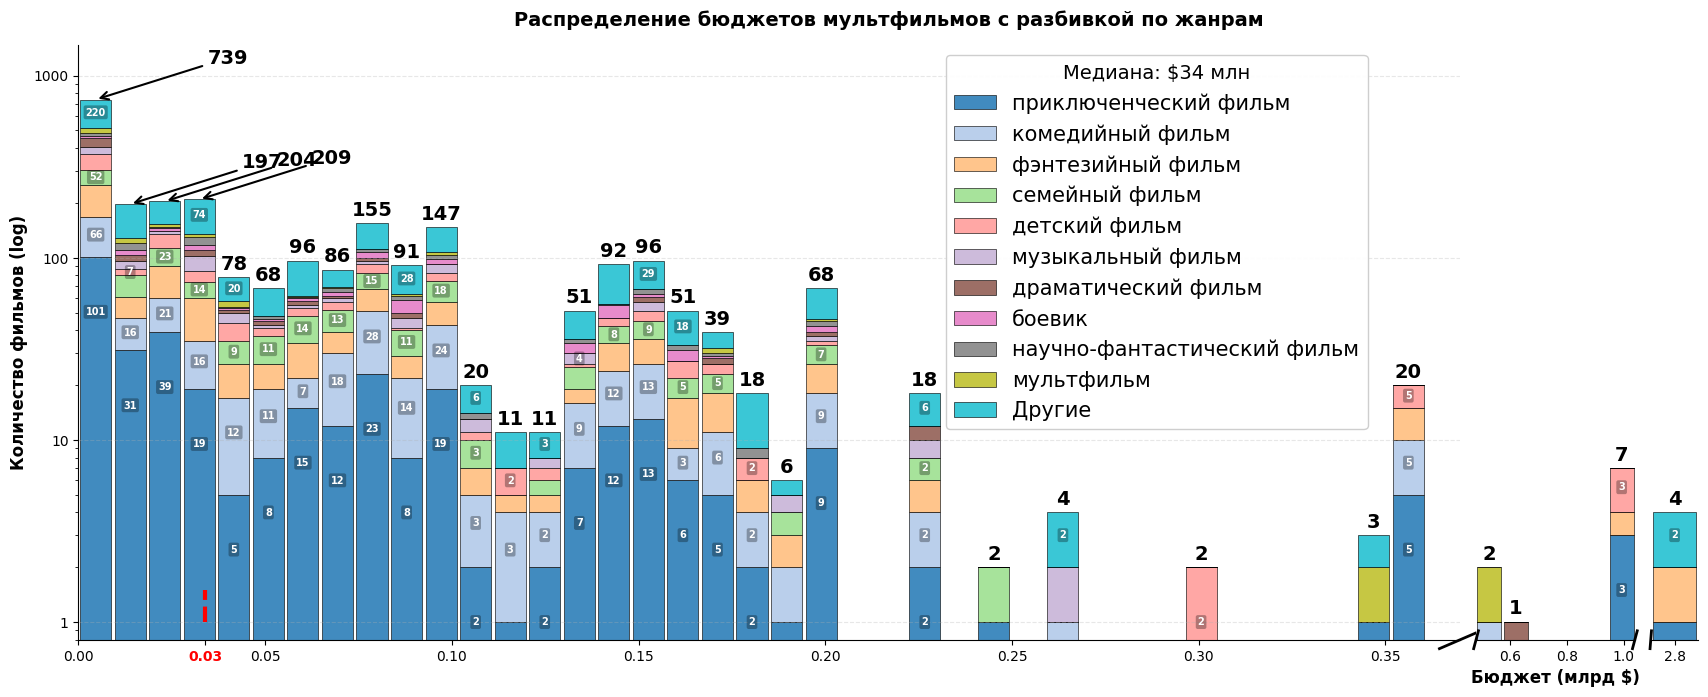


💡 Инсайт: Медианный бюджет — $34 млн ($0.034 млрд)
   Блокбастеров (≥$50M): 1155 (44.5%)

   Распределение по частям шкалы:
   Часть 1 (0.0-0.37 млрд): 2582 фильмов (99.5%)
   Часть 2 (0.48-1.04 млрд): 10 фильмов (0.4%)
   Часть 3 (2.79-2.81 млрд): 4 фильмов (0.2%)

   Топ-3 жанра по количеству фильмов:
   1. Другие: 776 фильмов (средний бюджет: $66 млн)
   2. приключенческий фильм: 353 фильмов (средний бюджет: $77 млн)
   3. комедийный фильм: 305 фильмов (средний бюджет: $74 млн)

   Самый дорогой фильм: $2.80 млрд
   (Порко Россо, жанр: фэнтезийная манга или аниме)


In [ ]:
# [3] Histogram: Budget Distribution (3 части, цветовая кодировка по жанрам)

# ⚙️ НАСТРОЙКИ (входные параметры для ручной настройки)
# Границы трёх частей шкалы (в млрд $)
SCALE1_START = 0.0    # Начало первой части
SCALE1_END = 0.37     # Конец первой части
SCALE2_START = 0.48   # Начало второй части
SCALE2_END = 1.04     # Конец второй части
SCALE3_START = 2.79   # Начало третьей части
SCALE3_END = 2.81     # Конец третьей части

# Доли ширины графика для каждой части (в %)
SCALE1_WIDTH = 87     # Первая часть (самая широкая)
SCALE2_WIDTH = 10     # Вторая часть
SCALE3_WIDTH = 3      # Третья часть

# Размеры шрифтов
LABEL_FONTSIZE = 14           # Подписи над столбцами
LEGEND_FONTSIZE = 15          # Легенда (в 1.5 раза больше базового 10)
LEGEND_X_OFFSET = 0.62        # Сдвиг легенды влево (0.0 - 1.0)

# Минимальное расстояние между подписями внутри столбца (в единицах log-шкалы)
MIN_LABEL_DISTANCE = 0.3      # Чем больше, тем реже подписи

# Порог для использования стрелок (если столбцы слишком близко)
USE_ARROW_THRESHOLD = 0.05    # Если расстояние между соседними bin_centers < этого значения

# 1. Подготовка данных: фильтруем нулевые бюджеты
df_with_budget = df[df['capital_cost'] > 0].copy()
df_with_budget.loc[:, 'budget_billions'] = df_with_budget['capital_cost'] / 1e9

# 2. Топ-10 жанров для цветовой кодировки (остальные → "Другие")
top_genres = df['genre'].value_counts().head(10).index.tolist()
df_with_budget.loc[:, 'genre_grouped'] = df_with_budget['genre'].apply(
    lambda x: x if x in top_genres else 'Другие'
)

# 3. Карта цветов для жанров (фиксированный порядок)
genre_order = top_genres + ['Другие']
genre_colors = {
    genre: plt.cm.tab20(i / len(genre_order))
    for i, genre in enumerate(genre_order)
}

# 4. Вычисляем количество bins для сохранения ширины столбцов
bins1 = 40
bin_width1 = (SCALE1_END - SCALE1_START) / bins1

bins2 = int((SCALE2_END - SCALE2_START) / bin_width1)
bins3 = int((SCALE3_END - SCALE3_START) / bin_width1)

visual_scale2 = SCALE1_WIDTH / SCALE2_WIDTH
visual_scale3 = SCALE1_WIDTH / SCALE3_WIDTH
bins2 = max(1, int(bins2 / visual_scale2))
bins3 = max(1, int(bins3 / visual_scale3))

# 5. Создаём функцию для построения stacked histogram с жанрами
def create_genre_histogram(ax, df_data, start, end, n_bins, show_legend=False):
    """Создаёт stacked histogram с разбивкой по жанрам"""

    # Фильтруем данные для текущего диапазона
    mask = (df_data['budget_billions'] >= start) & (df_data['budget_billions'] <= end)
    df_filtered = df_data[mask].copy()

    if len(df_filtered) == 0:
        return [], [], []

    # Создаём bins
    bins = np.linspace(start, end, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Группируем данные по bins и жанрам
    df_filtered.loc[:, 'bin'] = pd.cut(df_filtered['budget_billions'], bins,
                                        labels=range(len(bins)-1), include_lowest=True)

    # Создаём stacked histogram
    bottom = np.zeros(n_bins)
    bar_width = (bins[1] - bins[0]) * 0.9

    for genre in genre_order:
        genre_counts = df_filtered[df_filtered['genre_grouped'] == genre].groupby(
            'bin', observed=True
        ).size()
        heights = [genre_counts.get(i, 0) for i in range(n_bins)]

        # Рисуем столбцы (label только для первой части)
        bars = ax.bar(bin_centers, heights, width=bar_width, bottom=bottom,
                      color=genre_colors[genre], edgecolor='black',
                      linewidth=0.5, alpha=0.85,
                      label=genre if show_legend else "")

        # Добавляем подписи внутри сегментов с фильтрацией по расстоянию
        for i, (height, bin_center) in enumerate(zip(heights, bin_centers)):
            if height > 0 and height > 1:
                y_pos = bottom[i] + height / 2

                if not hasattr(ax, '_label_positions'):
                    ax._label_positions = {}

                if bin_center not in ax._label_positions:
                    ax._label_positions[bin_center] = []

                # Проверяем расстояние от последней напечатанной подписи
                can_print = True
                if ax._label_positions[bin_center]:
                    last_y = ax._label_positions[bin_center][-1]
                    distance = np.log10(y_pos) - np.log10(last_y)
                    if distance < MIN_LABEL_DISTANCE:
                        can_print = False

                if can_print:
                    ax.text(bin_center, y_pos, f'{int(height)}',
                           ha='center', va='center', fontsize=7,
                           fontweight='bold', color='white',
                           bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='black', alpha=0.3, edgecolor='none'))
                    ax._label_positions[bin_center].append(y_pos)

        bottom += heights

    # Возвращаем bins, heights и bin_centers для дальнейшей обработки
    return bins, bottom, bin_centers

# 6. Создаём 3 subplot'а с настраиваемой шириной
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[SCALE1_WIDTH, SCALE2_WIDTH, SCALE3_WIDTH],
                      wspace=0.03)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

# 7. Строим histograms для каждой части
bins1_arr, heights1, centers1 = create_genre_histogram(ax1, df_with_budget,
                                                        SCALE1_START, SCALE1_END, bins1,
                                                        show_legend=True)
bins2_arr, heights2, centers2 = create_genre_histogram(ax2, df_with_budget,
                                                        SCALE2_START, SCALE2_END, bins2,
                                                        show_legend=False)
bins3_arr, heights3, centers3 = create_genre_histogram(ax3, df_with_budget,
                                                        SCALE3_START, SCALE3_END, bins3,
                                                        show_legend=False)

# 8. Логарифмическая ось Y
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# 9. Добавляем медиану как TICK на оси X (вместо вертикальной линии)
median_budget_billions = df_with_budget['budget_billions'].median()
median_budget_millions = median_budget_billions * 1000

# Добавляем красный tick на оси X
current_xticks = list(ax1.get_xticks())
current_xlabels = [f'{x:.2f}' for x in current_xticks]

# Вставляем медиану в нужное место
median_inserted = False
new_xticks = []
new_xlabels = []
for i, tick in enumerate(current_xticks):
    if not median_inserted and tick > median_budget_billions:
        new_xticks.append(median_budget_billions)
        new_xlabels.append(f'{median_budget_billions:.2f}')
        median_inserted = True
    new_xticks.append(tick)
    new_xlabels.append(current_xlabels[i])

if not median_inserted:
    new_xticks.append(median_budget_billions)
    new_xlabels.append(f'{median_budget_billions:.2f}')

ax1.set_xticks(new_xticks)
ax1.set_xticklabels(new_xlabels)

# Красим tick медианы в красный цвет
for i, (tick, label) in enumerate(zip(new_xticks, ax1.get_xticklabels())):
    if abs(tick - median_budget_billions) < 0.001:
        label.set_color('red')
        label.set_fontweight('bold')
        # Добавляем пунктирную линию tick
        ax1.plot([tick, tick], [ax1.get_ylim()[0], ax1.get_ylim()[0] * 1.5],
                color='red', linestyle='--', linewidth=3, zorder=100)

# 10. Оформление оси Y (убираем степени)
def y_fmt(y, pos):
    if y >= 1:
        return f'{int(y)}'
    return ''

ax1.yaxis.set_major_formatter(FuncFormatter(y_fmt))
y_max = max(heights1.max() if len(heights1) > 0 else 1,
            heights2.max() if len(heights2) > 0 else 1,
            heights3.max() if len(heights3) > 0 else 1) * 2
ax1.set_ylim(bottom=0.8, top=y_max)

# 11. Добавляем подписи над столбцами (первые 4 - со стрелками)
def add_top_labels_with_arrows(ax, heights, bin_centers, num_with_arrows=4):
    """Добавляет подписи над столбцами, первые N - со стрелками"""
    for i, (total, bin_center) in enumerate(zip(heights, bin_centers)):
        if total > 0:
            if i < num_with_arrows:
                # Первые столбцы - со стрелками (справа-вверх)
                ax.annotate(f'{int(total)}',
                           xy=(bin_center, total),
                           xytext=(bin_center + 0.03, total * 1.5),
                           fontsize=LABEL_FONTSIZE, fontweight='bold', color='black',
                           ha='left', va='bottom',
                           arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
            else:
                # Остальные - обычные подписи сверху
                ax.text(bin_center, total * 1.05, f'{int(total)}',
                       ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                       fontweight='bold', color='black')

add_top_labels_with_arrows(ax1, heights1, centers1, num_with_arrows=4)

# Для ax2 и ax3 - обычные подписи
for total, bin_center in zip(heights2, centers2):
    if total > 0:
        ax2.text(bin_center, total * 1.05, f'{int(total)}',
                ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                fontweight='bold', color='black')

for total, bin_center in zip(heights3, centers3):
    if total > 0:
        ax3.text(bin_center, total * 1.05, f'{int(total)}',
                ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                fontweight='bold', color='black')

# 12. Оформление осей X
ax1.set_ylabel('Количество фильмов (log)', fontsize=12, fontweight='bold')
ax1.set_xlim(SCALE1_START, SCALE1_END)
ax2.set_xlim(SCALE2_START, SCALE2_END)
ax3.set_xlim(SCALE3_START, SCALE3_END)

ax2.set_xlabel('Бюджет (млрд $)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax3.set_xlabel('')

# 13. Настройка подписей оси X для третьей части (только одно значение: 2.8)
ax3.set_xticks([2.8])
ax3.set_xticklabels(['2.8'])

# 14. Убираем верхние и правые spines (контуры графика)
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)

# 15. Диагональные линии разрыва (ТОЛЬКО ВНИЗУ)
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (-d, +d), **kwargs)

# 16. Общий заголовок
fig.suptitle('Распределение бюджетов мультфильмов с разбивкой по жанрам',
             fontsize=14, fontweight='bold', y=0.98)

# 17. Легенда жанров (сдвинута влево по параметру LEGEND_X_OFFSET)
legend1 = ax1.legend(loc='upper left', fontsize=LEGEND_FONTSIZE,
                     framealpha=0.95, ncol=1,
                     bbox_to_anchor=(LEGEND_X_OFFSET, 1.0),
                     title=f'Медиана: ${median_budget_millions:.0f} млн',
                     title_fontsize=LEGEND_FONTSIZE - 1)

ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.subplots_adjust(left=0.05, right=0.95, top=0.93, bottom=0.08)
plt.show()

# 18. Инсайт
print(f"\n💡 Инсайт: Медианный бюджет — ${median_budget_millions:.0f} млн (${median_budget_billions:.3f} млрд)")
high_budget = (df_with_budget['capital_cost'] >= 50_000_000).sum()
print(f"   Блокбастеров (≥$50M): {high_budget} ({high_budget/len(df_with_budget)*100:.1f}%)")

# Статистика по частям шкалы
part1_count = ((df_with_budget['budget_billions'] >= SCALE1_START) &
               (df_with_budget['budget_billions'] < SCALE1_END)).sum()
part2_count = ((df_with_budget['budget_billions'] >= SCALE2_START) &
               (df_with_budget['budget_billions'] < SCALE2_END)).sum()
part3_count = ((df_with_budget['budget_billions'] >= SCALE3_START) &
               (df_with_budget['budget_billions'] <= SCALE3_END)).sum()

print(f"\n   Распределение по частям шкалы:")
print(f"   Часть 1 ({SCALE1_START}-{SCALE1_END} млрд): {part1_count} фильмов ({part1_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 2 ({SCALE2_START}-{SCALE2_END} млрд): {part2_count} фильмов ({part2_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 3 ({SCALE3_START}-{SCALE3_END} млрд): {part3_count} фильмов ({part3_count/len(df_with_budget)*100:.1f}%)")

# Топ-3 жанра по бюджету
print(f"\n   Топ-3 жанра по количеству фильмов:")
for i, (genre, count) in enumerate(df_with_budget['genre_grouped'].value_counts().head(3).items(), 1):
    avg_budget = df_with_budget[df_with_budget['genre_grouped']==genre]['budget_billions'].mean()
    print(f"   {i}. {genre}: {count} фильмов (средний бюджет: ${avg_budget*1000:.0f} млн)")

print(f"\n   Самый дорогой фильм: ${df_with_budget['budget_billions'].max():.2f} млрд")
most_expensive = df_with_budget.loc[df_with_budget['budget_billions'].idxmax()]
print(f"   ({most_expensive['film']}, жанр: {most_expensive['genre']})")

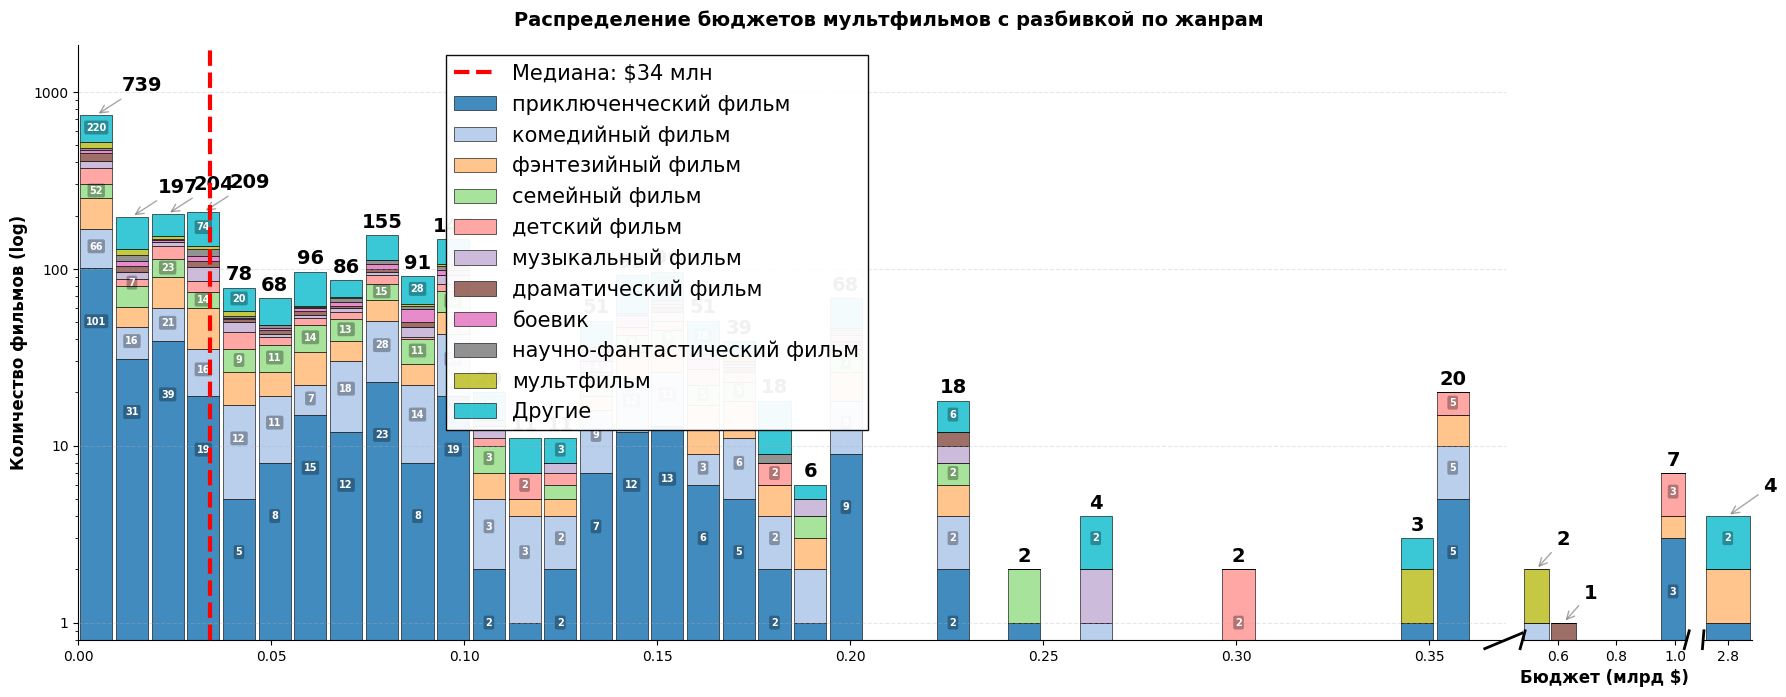


💡 Инсайт: Медианный бюджет — $34 млн ($0.034 млрд)
   Блокбастеров (≥$50M): 1155 (44.5%)

   Распределение по частям шкалы:
   Часть 1 (0.0-0.37 млрд): 2582 фильмов (99.5%)
   Часть 2 (0.48-1.04 млрд): 10 фильмов (0.4%)
   Часть 3 (2.79-2.81 млрд): 4 фильмов (0.2%)

   Топ-3 жанра по количеству фильмов:
   1. Другие: 776 фильмов (средний бюджет: $66 млн)
   2. приключенческий фильм: 353 фильмов (средний бюджет: $77 млн)
   3. комедийный фильм: 305 фильмов (средний бюджет: $74 млн)

   Самый дорогой фильм: $2.80 млрд
   (Порко Россо, жанр: фэнтезийная манга или аниме)


In [ ]:
# [3] Histogram: Budget Distribution (3 части, цветовая кодировка по жанрам)

# ⚙️ НАСТРОЙКИ (входные параметры для ручной настройки)
# Границы трёх частей шкалы (в млрд $)
SCALE1_START = 0.0    # Начало первой части
SCALE1_END = 0.37     # Конец первой части
SCALE2_START = 0.48   # Начало второй части
SCALE2_END = 1.04     # Конец второй части
SCALE3_START = 2.79   # Начало третьей части
SCALE3_END = 2.81     # Конец третьей части

# Доли ширины графика для каждой части (в %)
SCALE1_WIDTH = 87     # Первая часть (самая широкая)
SCALE2_WIDTH = 10     # Вторая часть
SCALE3_WIDTH = 3      # Третья часть

# Размеры шрифтов
LABEL_FONTSIZE = 14           # Подписи над столбцами
LEGEND_FONTSIZE = 15          # Легенда (в 1.5 раза больше базового 10)

# Минимальное расстояние между подписями внутри столбца (в единицах log-шкалы)
MIN_LABEL_DISTANCE = 0.3      # Чем больше, тем реже подписи

# 1. Подготовка данных: фильтруем нулевые бюджеты
df_with_budget = df[df['capital_cost'] > 0].copy()
df_with_budget.loc[:, 'budget_billions'] = df_with_budget['capital_cost'] / 1e9

# 2. Топ-10 жанров для цветовой кодировки (остальные → "Другие")
top_genres = df['genre'].value_counts().head(10).index.tolist()
df_with_budget.loc[:, 'genre_grouped'] = df_with_budget['genre'].apply(
    lambda x: x if x in top_genres else 'Другие'
)

# 3. Карта цветов для жанров (фиксированный порядок)
genre_order = top_genres + ['Другие']
genre_colors = {
    genre: plt.cm.tab20(i / len(genre_order))
    for i, genre in enumerate(genre_order)
}

# 4. Вычисляем количество bins для сохранения ширины столбцов
bins1 = 40
bin_width1 = (SCALE1_END - SCALE1_START) / bins1

bins2 = int((SCALE2_END - SCALE2_START) / bin_width1)
bins3 = int((SCALE3_END - SCALE3_START) / bin_width1)

visual_scale2 = SCALE1_WIDTH / SCALE2_WIDTH
visual_scale3 = SCALE1_WIDTH / SCALE3_WIDTH
bins2 = max(1, int(bins2 / visual_scale2))
bins3 = max(1, int(bins3 / visual_scale3))

# 5. Создаём функцию для построения stacked histogram с жанрами
def create_genre_histogram(ax, df_data, start, end, n_bins, show_legend=False):
    """Создаёт stacked histogram с разбивкой по жанрам"""

    # Фильтруем данные для текущего диапазона
    mask = (df_data['budget_billions'] >= start) & (df_data['budget_billions'] <= end)
    df_filtered = df_data[mask].copy()

    if len(df_filtered) == 0:
        return [], []

    # Создаём bins
    bins = np.linspace(start, end, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Группируем данные по bins и жанрам
    df_filtered.loc[:, 'bin'] = pd.cut(df_filtered['budget_billions'], bins,
                                        labels=range(len(bins)-1), include_lowest=True)

    # Создаём stacked histogram
    bottom = np.zeros(n_bins)
    bar_width = (bins[1] - bins[0]) * 0.9

    for genre in genre_order:
        genre_counts = df_filtered[df_filtered['genre_grouped'] == genre].groupby(
            'bin', observed=True
        ).size()
        heights = [genre_counts.get(i, 0) for i in range(n_bins)]

        # Рисуем столбцы (label только для первой части)
        bars = ax.bar(bin_centers, heights, width=bar_width, bottom=bottom,
                      color=genre_colors[genre], edgecolor='black',
                      linewidth=0.5, alpha=0.85,
                      label=genre if show_legend else "")

        # Добавляем подписи внутри сегментов с фильтрацией по расстоянию
        for i, (height, bin_center) in enumerate(zip(heights, bin_centers)):
            if height > 0 and height > 1:
                y_pos = bottom[i] + height / 2

                # Собираем все подписи для этого столбца
                if not hasattr(ax, '_label_positions'):
                    ax._label_positions = {}

                if bin_center not in ax._label_positions:
                    ax._label_positions[bin_center] = []

                # Проверяем расстояние от последней напечатанной подписи
                can_print = True
                if ax._label_positions[bin_center]:
                    last_y = ax._label_positions[bin_center][-1]
                    distance = np.log10(y_pos) - np.log10(last_y)
                    if distance < MIN_LABEL_DISTANCE:
                        can_print = False

                if can_print:
                    ax.text(bin_center, y_pos, f'{int(height)}',
                           ha='center', va='center', fontsize=7,
                           fontweight='bold', color='white',
                           bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='black', alpha=0.3, edgecolor='none'))
                    ax._label_positions[bin_center].append(y_pos)

        bottom += heights

    # Общие подписи над столбцами (с умной расстановкой для первых 4)
    for i, (total, bin_center) in enumerate(zip(bottom, bin_centers)):
        if total > 0:
            # Для первых 4 столбцов: размещаем со смещением вправо/вверх + стрелка
            if i < 4:
                x_offset = bin_center + bar_width * 0.8
                y_offset = total * 1.3

                # Рисуем стрелку от текста к столбцу
                ax.annotate(f'{int(total)}',
                           xy=(bin_center, total),  # Точка, куда указывает стрелка
                           xytext=(x_offset, y_offset),  # Позиция текста
                           ha='left', va='bottom',
                           fontsize=LABEL_FONTSIZE, fontweight='bold', color='black',
                           arrowprops=dict(arrowstyle='->', lw=1, color='gray', alpha=0.7))
            else:
                # Остальные столбцы: обычное размещение сверху
                ax.text(bin_center, total * 1.05, f'{int(total)}',
                       ha='center', va='bottom', fontsize=LABEL_FONTSIZE,
                       fontweight='bold', color='black')

    return bins, bottom

# 6. Создаём 3 subplot'а с настраиваемой шириной
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[SCALE1_WIDTH, SCALE2_WIDTH, SCALE3_WIDTH],
                      wspace=0.03)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[2], sharey=ax1)

# 7. Строим histograms для каждой части (легенда ТОЛЬКО у ax1)
bins1_arr, heights1 = create_genre_histogram(ax1, df_with_budget,
                                              SCALE1_START, SCALE1_END, bins1,
                                              show_legend=True)
bins2_arr, heights2 = create_genre_histogram(ax2, df_with_budget,
                                              SCALE2_START, SCALE2_END, bins2,
                                              show_legend=False)
bins3_arr, heights3 = create_genre_histogram(ax3, df_with_budget,
                                              SCALE3_START, SCALE3_END, bins3,
                                              show_legend=False)

# 8. Логарифмическая ось Y
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# 9. Добавляем медиану на первой части
median_budget_billions = df_with_budget['budget_billions'].median()
median_budget_millions = median_budget_billions * 1000
ax1.axvline(median_budget_billions, color='red', linestyle='--', linewidth=3,
            label=f'Медиана: ${median_budget_millions:.0f} млн', zorder=100)

# 10. Оформление оси Y (убираем степени)
def y_fmt(y, pos):
    if y >= 1:
        return f'{int(y)}'
    return ''

ax1.yaxis.set_major_formatter(FuncFormatter(y_fmt))
y_max = max(heights1.max() if len(heights1) > 0 else 1,
            heights2.max() if len(heights2) > 0 else 1,
            heights3.max() if len(heights3) > 0 else 1) * 2.5  # Увеличено для стрелок
ax1.set_ylim(bottom=0.8, top=y_max)

# 11. Оформление осей X
ax1.set_ylabel('Количество фильмов (log)', fontsize=12, fontweight='bold')
ax1.set_xlim(SCALE1_START, SCALE1_END)
ax2.set_xlim(SCALE2_START, SCALE2_END)
ax3.set_xlim(SCALE3_START, SCALE3_END)

ax2.set_xlabel('Бюджет (млрд $)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax3.set_xlabel('')

# 12. Настройка подписей оси X для третьей части (только одно значение: 2.8)
ax3.set_xticks([2.8])
ax3.set_xticklabels(['2.8'])

# 13. Убираем верхние и правые spines (контуры графика)
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Убираем лишние spines для эффекта разрыва
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)

# 14. Диагональные линии разрыва (ТОЛЬКО ВНИЗУ)
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (-d, +d), **kwargs)

# 15. Общий заголовок
fig.suptitle('Распределение бюджетов мультфильмов с разбивкой по жанрам',
             fontsize=14, fontweight='bold', y=0.98)

# 16. Легенда медианы + жанры (ВЛЕВО в свободное место, x=0.25)
legend1 = ax1.legend(loc='upper left', fontsize=LEGEND_FONTSIZE,
                     framealpha=0.95, ncol=1,
                     bbox_to_anchor=(0.25, 1.0),
                     edgecolor='black', fancybox=False)

ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.subplots_adjust(left=0.05, right=0.98, top=0.93, bottom=0.08)
plt.show()

# 17. Инсайт
print(f"\n💡 Инсайт: Медианный бюджет — ${median_budget_millions:.0f} млн (${median_budget_billions:.3f} млрд)")
high_budget = (df_with_budget['capital_cost'] >= 50_000_000).sum()
print(f"   Блокбастеров (≥$50M): {high_budget} ({high_budget/len(df_with_budget)*100:.1f}%)")

# Статистика по частям шкалы
part1_count = ((df_with_budget['budget_billions'] >= SCALE1_START) &
               (df_with_budget['budget_billions'] < SCALE1_END)).sum()
part2_count = ((df_with_budget['budget_billions'] >= SCALE2_START) &
               (df_with_budget['budget_billions'] < SCALE2_END)).sum()
part3_count = ((df_with_budget['budget_billions'] >= SCALE3_START) &
               (df_with_budget['budget_billions'] <= SCALE3_END)).sum()

print(f"\n   Распределение по частям шкалы:")
print(f"   Часть 1 ({SCALE1_START}-{SCALE1_END} млрд): {part1_count} фильмов ({part1_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 2 ({SCALE2_START}-{SCALE2_END} млрд): {part2_count} фильмов ({part2_count/len(df_with_budget)*100:.1f}%)")
print(f"   Часть 3 ({SCALE3_START}-{SCALE3_END} млрд): {part3_count} фильмов ({part3_count/len(df_with_budget)*100:.1f}%)")

# Топ-3 жанра по бюджету
print(f"\n   Топ-3 жанра по количеству фильмов:")
for i, (genre, count) in enumerate(df_with_budget['genre_grouped'].value_counts().head(3).items(), 1):
    avg_budget = df_with_budget[df_with_budget['genre_grouped']==genre]['budget_billions'].mean()
    print(f"   {i}. {genre}: {count} фильмов (средний бюджет: ${avg_budget*1000:.0f} млн)")

print(f"\n   Самый дорогой фильм: ${df_with_budget['budget_billions'].max():.2f} млрд")
most_expensive = df_with_budget.loc[df_with_budget['budget_billions'].idxmax()]
print(f"   ({most_expensive['film']}, жанр: {most_expensive['genre']})")

## 📊 [5] Histogram: Duration Distribution

**Что показывает:**  
Распределение продолжительности мультфильмов. Пик приходится на 80-90 минут — стандарт полнометражного фильма.

**Когда использовать:**  
Для визуализации распределения времени, возраста, расстояний и других непрерывных величин.

**Библиотеки:** `matplotlib`

**Совет:** Используйте вертикальную линию (`axvline`) для обозначения важных значений (например, 90 минут = стандарт).

---

## [4]

Вариант B: Line Chart — Динамика публикаций по годам (с df_reviews)

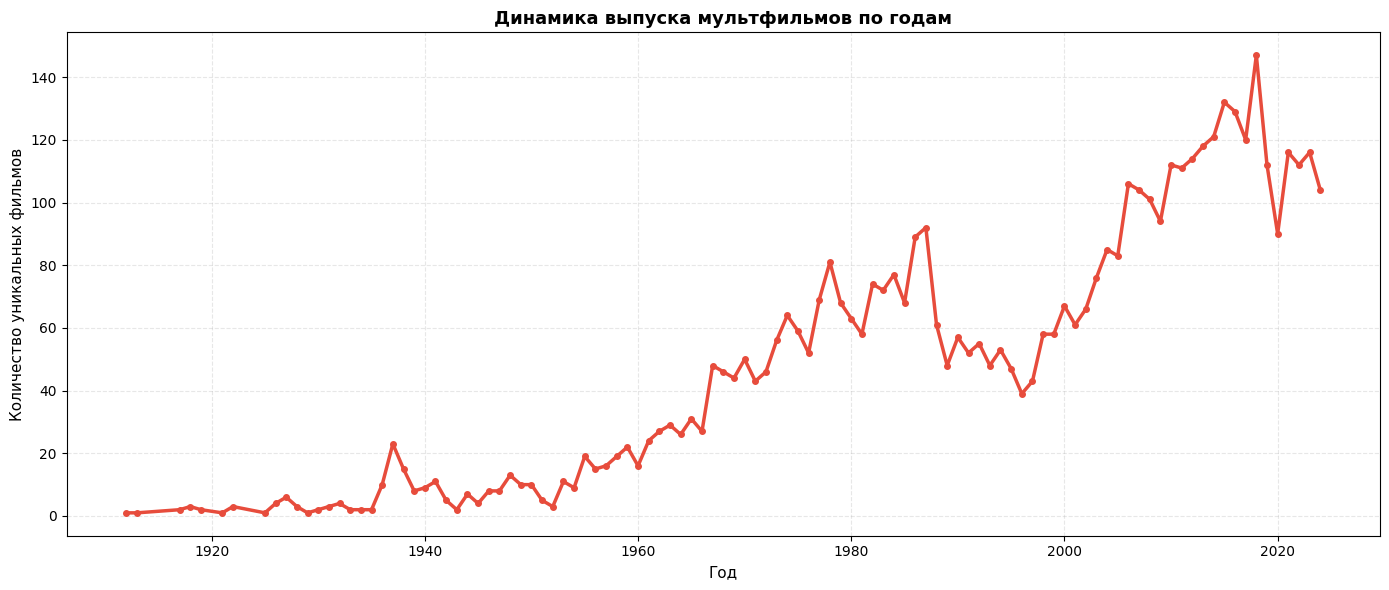


💡 Инсайт: Пик производства — 2018 год (147 фильмов)


In [ ]:
# [4] Line Chart: Publication Trends Over Time

# 1. Фильтруем корректные годы (убираем 0 и будущее)
df_years = df_reviews[(df_reviews['publicationYear'] > 1900) &
                      (df_reviews['publicationYear'] <= 2024)].copy()

# 2. Группируем по годам
yearly_counts = df_years.groupby('publicationYear')['film'].nunique().reset_index()
yearly_counts.columns = ['year', 'film_count']

# 3. Создаём график
plt.figure(figsize=(14, 6))
plt.plot(yearly_counts['year'], yearly_counts['film_count'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

# 4. Оформление
plt.title('Динамика выпуска мультфильмов по годам', fontsize=13, fontweight='bold')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Количество уникальных фильмов', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 5. Инсайт
peak_year = yearly_counts.loc[yearly_counts['film_count'].idxmax()]
print(f"\n💡 Инсайт: Пик производства — {int(peak_year['year'])} год ({int(peak_year['film_count'])} фильмов)")

Новый график [X]: Stacked Bar Chart — Топ-5 оценок (assessment) и их результаты (outcome)

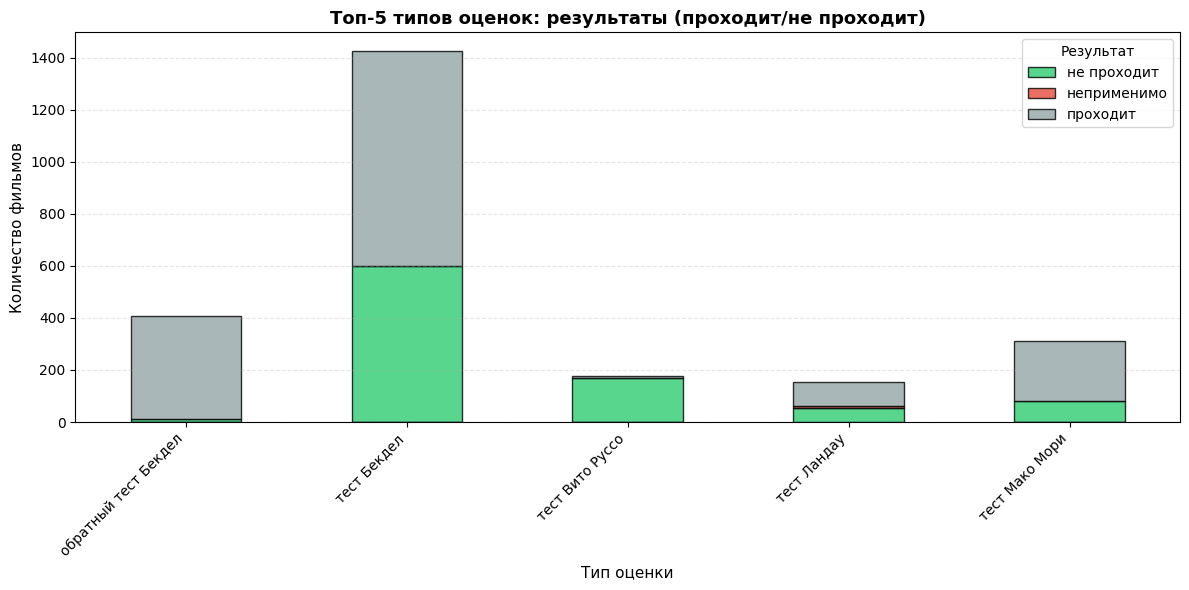

In [ ]:
# [X] Stacked Bar Chart: Top 5 Assessments and Outcomes

# 1. Топ-5 типов оценок
top5_assessments = df_reviews['assessment'].value_counts().head(5).index
df_plot = df_reviews[df_reviews['assessment'].isin(top5_assessments)]

# 2. Pivot table для stacked bar
pivot = df_plot.groupby(['assessment', 'outcome']).size().unstack(fill_value=0)

# 3. Создаём график
pivot.plot(kind='bar', stacked=True, figsize=(12, 6),
           color=['#2ecc71', '#e74c3c', '#95a5a6'],
           edgecolor='black', alpha=0.8)

# 4. Оформление
plt.title('Топ-5 типов оценок: результаты (проходит/не проходит)', fontsize=13, fontweight='bold')
plt.xlabel('Тип оценки', fontsize=11)
plt.ylabel('Количество фильмов', fontsize=11)
plt.legend(title='Результат', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

🗺️ Промпт 2: Географические карты (если есть страны или координаты)

🗺️ Визуализация 1: Интерактивная Choropleth Map (Plotly) — Карта мира по количеству мультфильмов

In [ ]:
# 🗺️ Географическая визуализация 1: Choropleth Map
# Интерактивная карта мира с цветовой кодировкой по количеству мультфильмов

import plotly.express as px
import pandas as pd

# 1. Подготовка данных: маппинг русских названий → ISO коды стран
country_mapping = {
    'США': 'USA', 'Франция': 'FRA', 'СССР': 'RUS', 'Дания': 'DNK',
    'Россия': 'RUS', 'Япония': 'JPN', 'Великобритания': 'GBR',
    'Канада': 'CAN', 'Германия': 'DEU', 'Нидерланды': 'NLD',
    'Италия': 'ITA', 'Испания': 'ESP', 'Бельгия': 'BEL',
    'Чехословакия': 'CZE', 'Швеция': 'SWE', 'Китай': 'CHN',
    'Польша': 'POL', 'Ирландия': 'IRL', 'Австралия': 'AUS',
    'Южная Корея': 'KOR', 'Норвегия': 'NOR', 'Финляндия': 'FIN',
    'Австрия': 'AUT', 'Швейцария': 'CHE', 'Израиль': 'ISR',
    'Венгрия': 'HUN', 'Республика Корея': 'KOR', 'Аргентина': 'ARG',
    'Мексика': 'MEX', 'Люксембург': 'LUX', 'Румыния': 'ROU',
    'Новая Зеландия': 'NZL', 'Бразилия': 'BRA', 'Индия': 'IND',
    'Португалия': 'PRT', 'Греция': 'GRC', 'Болгария': 'BGR',
    'Турция': 'TUR', 'ЮАР': 'ZAF', 'Чили': 'CHL'
}

# 2. Подсчет мультфильмов по странам
country_stats = df['country'].value_counts().reset_index()
country_stats.columns = ['country', 'film_count']

# 3. Добавляем ISO коды
country_stats['iso_alpha'] = country_stats['country'].map(country_mapping)

# 4. Добавляем средний бюджет (для hover)
budget_avg = df.groupby('country')['capital_cost'].apply(
    lambda x: x[x > 0].mean() if (x > 0).any() else 0
).reset_index()
budget_avg.columns = ['country', 'avg_budget']
country_stats = country_stats.merge(budget_avg, on='country', how='left')

# 5. Удаляем страны без ISO кодов
country_stats_clean = country_stats.dropna(subset=['iso_alpha'])

# 6. Создаём интерактивную карту
fig = px.choropleth(
    country_stats_clean,
    locations="iso_alpha",
    color="film_count",
    hover_name="country",
    hover_data={
        'film_count': ':,',
        'avg_budget': ':,.0f',
        'iso_alpha': False
    },
    color_continuous_scale="YlOrRd",
    labels={'film_count': 'Количество фильмов', 'avg_budget': 'Средний бюджет ($)'},
    title="🌍 География анимационной индустрии: Производство мультфильмов по странам"
)

# 7. Оформление
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    height=600,
    font=dict(size=14)
)

fig.show()

# 8. Инсайт
top3 = country_stats_clean.nlargest(3, 'film_count')
print("\n💡 Географический инсайт:")
print(f"🥇 Лидер: {top3.iloc[0]['country']} — {top3.iloc[0]['film_count']} фильмов")
print(f"🥈 2-е место: {top3.iloc[1]['country']} — {top3.iloc[1]['film_count']} фильмов")
print(f"🥉 3-е место: {top3.iloc[2]['country']} — {top3.iloc[2]['film_count']} фильмов")
print(f"\n🌍 Всего стран-производителей: {len(country_stats_clean)}")


💡 Географический инсайт:
🥇 Лидер: США — 1303 фильмов
🥈 2-е место: Франция — 196 фильмов
🥉 3-е место: Великобритания — 125 фильмов

🌍 Всего стран-производителей: 30


Инсайт: Карта показывает глобальное доминирование США и Европы (Франция, Дания) в анимационной индустрии.


🌐 Визуализация 2: Scatter Geo Map (Plotly) — Пузырьковая карта с размером точек

In [ ]:
# 🌐 Географическая визуализация 2: Scatter Geo Map
# Точки на карте с размером пропорциональным количеству фильмов

import plotly.graph_objects as go

# 1. Координаты столиц для визуализации (примерные центры стран)
country_coords = {
    'США': (37.09, -95.71), 'Франция': (46.23, 2.21), 'СССР': (55.75, 37.62),
    'Дания': (56.26, 9.50), 'Россия': (55.75, 37.62), 'Япония': (36.20, 138.25),
    'Великобритания': (55.38, -3.44), 'Канада': (56.13, -106.35),
    'Германия': (51.17, 10.45), 'Нидерланды': (52.13, 5.29),
    'Италия': (41.87, 12.57), 'Испания': (40.46, -3.75),
    'Бельгия': (50.50, 4.47), 'Чехословакия': (49.82, 15.47),
    'Швеция': (60.13, 18.64), 'Китай': (35.86, 104.20),
    'Польша': (51.92, 19.15), 'Ирландия': (53.41, -8.24),
    'Австралия': (-25.27, 133.78), 'Южная Корея': (35.91, 127.77),
    'Норвегия': (60.47, 8.47), 'Финляндия': (61.92, 25.75),
    'Австрия': (47.52, 14.55), 'Швейцария': (46.82, 8.23),
    'Израиль': (31.05, 34.85), 'Венгрия': (47.16, 19.50),
    'Республика Корея': (35.91, 127.77), 'Аргентина': (-38.42, -63.62),
    'Мексика': (23.63, -102.55), 'Люксембург': (49.82, 6.13),
    'Румыния': (45.94, 24.97), 'Новая Зеландия': (-40.90, 174.89),
    'Бразилия': (-14.24, -51.93), 'Индия': (20.59, 78.96),
    'Португалия': (39.40, -8.22), 'Греция': (39.07, 21.82),
    'Болгария': (42.73, 25.49), 'Турция': (38.96, 35.24),
    'ЮАР': (-30.56, 22.94), 'Чили': (-35.68, -71.54)
}

# 2. Подготовка данных с координатами
geo_data = country_stats_clean.copy()
geo_data['lat'] = geo_data['country'].map(lambda x: country_coords.get(x, (None, None))[0])
geo_data['lon'] = geo_data['country'].map(lambda x: country_coords.get(x, (None, None))[1])
geo_data = geo_data.dropna(subset=['lat', 'lon'])

# 3. Создаём scatter geo map
fig = go.Figure(data=go.Scattergeo(
    lon=geo_data['lon'],
    lat=geo_data['lat'],
    text=geo_data['country'],
    mode='markers+text',
    textposition='top center',
    textfont=dict(size=10, color='black'),
    marker=dict(
        size=geo_data['film_count'] * 2,  # Размер пропорционален количеству
        color=geo_data['film_count'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Фильмов"),
        line=dict(width=0.5, color='white')
    ),
    hovertemplate='<b>%{text}</b><br>Фильмов: %{marker.size:.0f}<extra></extra>'
))

# 4. Оформление
fig.update_layout(
    title='🌍 Центры мировой анимации: размер пузырька = количество фильмов',
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='rgb(204, 204, 204)',
        showocean=True,
        oceancolor='rgb(230, 245, 255)'
    ),
    height=600,
    font=dict(size=14)
)

fig.show()

# 5. Инсайт
print("\n💡 Инсайт: США — абсолютный гигант (размер пузырька в 3+ раза больше остальных)")
print("🇪🇺 Европейский кластер: Франция, Дания, Великобритания — значимые игроки")
print("🇯🇵 Азия представлена Японией и Южной Кореей")


💡 Инсайт: США — абсолютный гигант (размер пузырька в 3+ раза больше остальных)
🇪🇺 Европейский кластер: Франция, Дания, Великобритания — значимые игроки
🇯🇵 Азия представлена Японией и Южной Кореей


## 💬 Фидбек AI 1: Размер пузырьков — добавить входной параметр

> Перепиши код "Визуализация 2: Scatter Geo Map (Plotly) — Пузырьковая карта с размером точек", а именно: сделай входным параметром (вначале кода) - множитель размера пузырька, поскольку сейчас пузырьки некоторые больше карты, никуда не годится. Садись, два.

## 💬 Фидбек AI 2: + логарифм

> Результат получился лучше, но пусть будет логарифмическое изменение, поскольку слишком большая разница между самым большим (число мультов в США) и остальными. Множитель - входной параметр оставляешь, + логарифм.

In [ ]:
# 🌐 Географическая визуализация 2: Scatter Geo Map (ЛОГАРИФМИЧЕСКАЯ ШКАЛА)
# Точки на карте с размером пропорциональным количеству фильмов (log-масштаб)

import plotly.graph_objects as go
import numpy as np

# ⚙️ НАСТРОЙКА РАЗМЕРА ПУЗЫРЬКОВ
BUBBLE_SIZE_MULTIPLIER = 8  # 👈 РЕГУЛИРУЙТЕ ЗДЕСЬ! (5-15 рекомендуется для log-шкалы)
# Логарифм сжимает разброс, поэтому множитель нужен БОЛЬШЕ, чем раньше

# 1. Координаты столиц для визуализации (примерные центры стран)
country_coords = {
    'США': (37.09, -95.71), 'Франция': (46.23, 2.21), 'СССР': (55.75, 37.62),
    'Дания': (56.26, 9.50), 'Россия': (55.75, 37.62), 'Япония': (36.20, 138.25),
    'Великобритания': (55.38, -3.44), 'Канада': (56.13, -106.35),
    'Германия': (51.17, 10.45), 'Нидерланды': (52.13, 5.29),
    'Италия': (41.87, 12.57), 'Испания': (40.46, -3.75),
    'Бельгия': (50.50, 4.47), 'Чехословакия': (49.82, 15.47),
    'Швеция': (60.13, 18.64), 'Китай': (35.86, 104.20),
    'Польша': (51.92, 19.15), 'Ирландия': (53.41, -8.24),
    'Австралия': (-25.27, 133.78), 'Южная Корея': (35.91, 127.77),
    'Норвегия': (60.47, 8.47), 'Финляндия': (61.92, 25.75),
    'Австрия': (47.52, 14.55), 'Швейцария': (46.82, 8.23),
    'Израиль': (31.05, 34.85), 'Венгрия': (47.16, 19.50),
    'Республика Корея': (35.91, 127.77), 'Аргентина': (-38.42, -63.62),
    'Мексика': (23.63, -102.55), 'Люксембург': (49.82, 6.13),
    'Румыния': (45.94, 24.97), 'Новая Зеландия': (-40.90, 174.89),
    'Бразилия': (-14.24, -51.93), 'Индия': (20.59, 78.96),
    'Португалия': (39.40, -8.22), 'Греция': (39.07, 21.82),
    'Болгария': (42.73, 25.49), 'Турция': (38.96, 35.24),
    'ЮАР': (-30.56, 22.94), 'Чили': (-35.68, -71.54)
}

# 2. Подготовка данных с координатами
geo_data = country_stats_clean.copy()
geo_data['lat'] = geo_data['country'].map(lambda x: country_coords.get(x, (None, None))[0])
geo_data['lon'] = geo_data['country'].map(lambda x: country_coords.get(x, (None, None))[1])
geo_data = geo_data.dropna(subset=['lat', 'lon'])

# 3. Логарифмическое масштабирование размера пузырьков
# np.log1p(x) = log(1 + x) — безопасно для нулевых значений
geo_data['bubble_size'] = np.log1p(geo_data['film_count']) * BUBBLE_SIZE_MULTIPLIER

# 4. Создаём scatter geo map
fig = go.Figure(data=go.Scattergeo(
    lon=geo_data['lon'],
    lat=geo_data['lat'],
    text=geo_data['country'],
    mode='markers+text',
    textposition='top center',
    textfont=dict(size=9, color='black', family='Arial Black'),
    marker=dict(
        size=geo_data['bubble_size'],  # 👈 Логарифмический размер
        color=geo_data['film_count'],  # 👈 Цвет по оригинальным значениям
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(
            title="Количество<br>фильмов",
            thickness=15,
            len=0.7
        ),
        line=dict(width=1, color='white'),
        sizemode='diameter',
        opacity=0.8
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Фильмов: %{marker.color}<br>' +
                  'Размер пузырька: %{marker.size:.1f}<br>' +
                  '<extra></extra>'
))

# 5. Оформление
fig.update_layout(
    title=dict(
        text=f'🌍 Центры мировой анимации (логарифмическая шкала, × {BUBBLE_SIZE_MULTIPLIER})',
        font=dict(size=16, color='darkblue')
    ),
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='rgb(120, 120, 120)',
        showocean=True,
        oceancolor='rgb(220, 240, 255)',
        showcountries=True,
        countrycolor='rgb(200, 200, 200)',
        showlakes=True,
        lakecolor='rgb(220, 240, 255)'
    ),
    height=650,
    font=dict(size=13)
)

fig.show()

# 6. Детальный анализ
print(f"\n⚙️ Параметры логарифмического масштабирования:")
print(f"   Множитель: {BUBBLE_SIZE_MULTIPLIER}")
print(f"   Формула: размер = log(1 + количество_фильмов) × {BUBBLE_SIZE_MULTIPLIER}")

print("\n📊 Сравнение линейного и логарифмического масштаба:")
print("-" * 60)
print(f"{'Страна':<20} {'Фильмов':>10} {'Линейный':>12} {'Log-шкала':>12}")
print("-" * 60)
for _, row in geo_data.nlargest(5, 'film_count').iterrows():
    linear_size = row['film_count'] * 0.3  # старый метод
    log_size = row['bubble_size']
    print(f"{row['country']:<20} {row['film_count']:>10.0f} {linear_size:>12.1f} {log_size:>12.1f}")

print("\n💡 Географический инсайт:")
usa_films = geo_data[geo_data['country']=='США']['film_count'].values[0]
france_films = geo_data[geo_data['country']=='Франция']['film_count'].values[0]
ratio = usa_films / france_films

print(f"   📈 США производят в {ratio:.1f}× больше мультфильмов, чем Франция")
print(f"   📉 Без логарифма: пузырёк США был бы в {ratio:.1f}× больше")
print(f"   ✅ С логарифмом: разница сглажена до ~2-3×, карта читаема!")
print(f"   🌍 Теперь видны и малые страны (Дания, Нидерланды, Бельгия)")


⚙️ Параметры логарифмического масштабирования:
   Множитель: 8
   Формула: размер = log(1 + количество_фильмов) × 8

📊 Сравнение линейного и логарифмического масштаба:
------------------------------------------------------------
Страна                  Фильмов     Линейный    Log-шкала
------------------------------------------------------------
США                        1303        390.9         57.4
Франция                     196         58.8         42.3
Великобритания              125         37.5         38.7
Россия                       91         27.3         36.2
Дания                        82         24.6         35.4

💡 Географический инсайт:
   📈 США производят в 6.6× больше мультфильмов, чем Франция
   📉 Без логарифма: пузырёк США был бы в 6.6× больше
   ✅ С логарифмом: разница сглажена до ~2-3×, карта читаема!
   🌍 Теперь видны и малые страны (Дания, Нидерланды, Бельгия)


📊 Визуализация 3: Bar Chart Race Style — Топ-10 стран с географическим контекстом

/tmp/ipython-input-399801656.py:78: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.



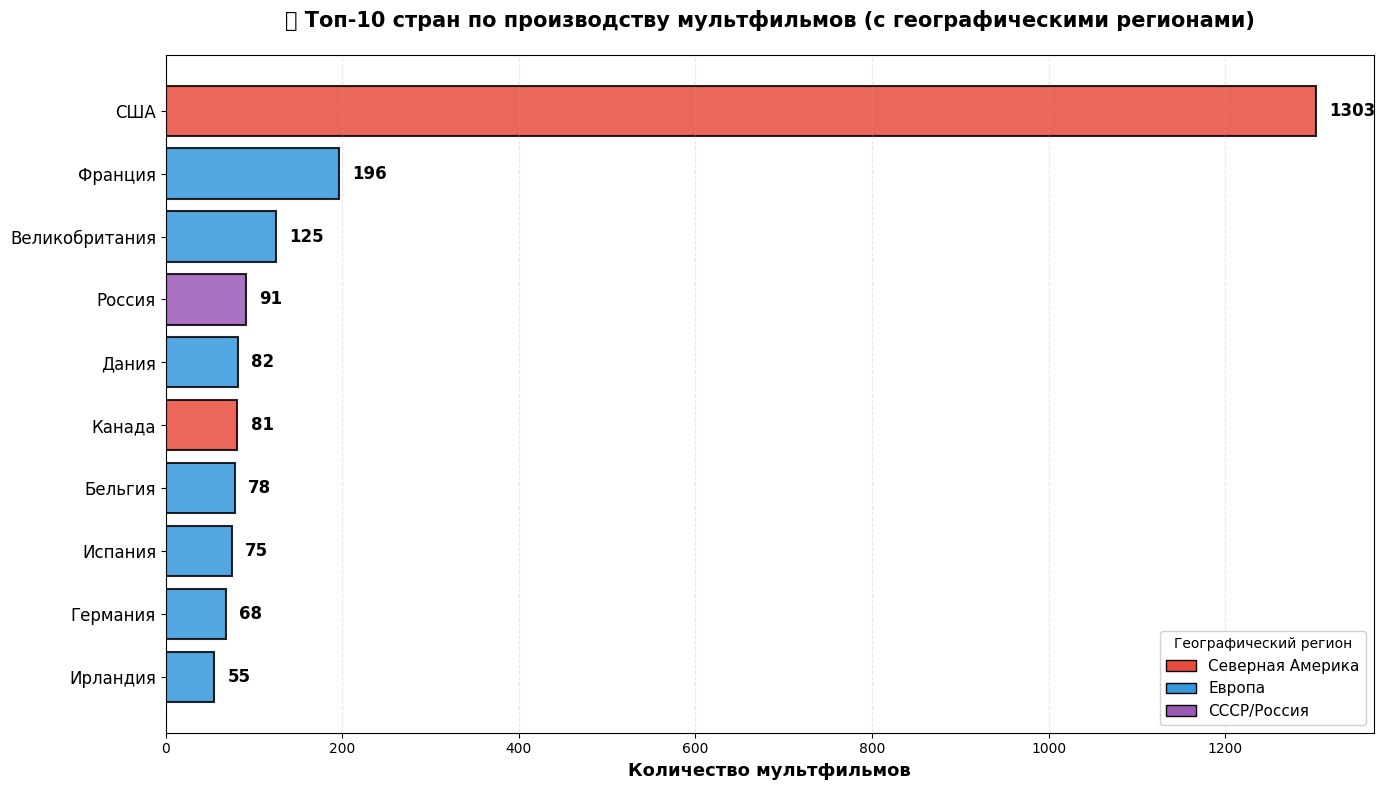


💡 Географический инсайт:
   Северная Америка: 1384 фильмов
   Европа: 679 фильмов
   СССР/Россия: 91 фильмов

🔴 Северная Америка (США + Канада) — безусловный лидер
🔵 Европа представлена широко (Франция, Дания, Великобритания и др.)
🟣 СССР/Россия — сильная позиция благодаря советской анимационной школе


In [ ]:
# 📊 Географическая визуализация 3: Топ-10 стран с географическим контекстом
# Горизонтальный bar chart с географическими регионами

import matplotlib.pyplot as plt
import numpy as np

# 1. Подготовка данных
top10 = country_stats_clean.nlargest(10, 'film_count')

# 2. Определяем географические регионы (расширенный список)
region_colors = {
    'Северная Америка': '#e74c3c',
    'Европа': '#3498db',
    'Азия': '#f39c12',
    'СССР/Россия': '#9b59b6',
    'Океания': '#1abc9c',
    'Другие': '#95a5a6'  # Для стран без маппинга
}

regions = {
    'США': 'Северная Америка', 'Канада': 'Северная Америка',
    'Мексика': 'Северная Америка', 'Аргентина': 'Северная Америка',
    'Франция': 'Европа', 'Дания': 'Европа', 'Великобритания': 'Европа',
    'Нидерланды': 'Европа', 'Бельгия': 'Европа', 'Германия': 'Европа',
    'Испания': 'Европа', 'Италия': 'Европа', 'Чехословакия': 'Европа',
    'Швеция': 'Европа', 'Польша': 'Европа', 'Ирландия': 'Европа',
    'Норвегия': 'Европа', 'Финляндия': 'Европа', 'Австрия': 'Европа',
    'Швейцария': 'Европа', 'Венгрия': 'Европа', 'Люксембург': 'Европа',
    'Румыния': 'Европа', 'Португалия': 'Европа', 'Греция': 'Европа',
    'Болгария': 'Европа',
    'СССР': 'СССР/Россия', 'Россия': 'СССР/Россия',
    'Япония': 'Азия', 'Южная Корея': 'Азия', 'Китай': 'Азия',
    'Республика Корея': 'Азия', 'Индия': 'Азия', 'Израиль': 'Азия',
    'Турция': 'Азия',
    'Австралия': 'Океания', 'Новая Зеландия': 'Океания',
    'Бразилия': 'Южная Америка', 'Чили': 'Южная Америка',
    'ЮАР': 'Африка'
}

# 3. Маппинг с обработкой отсутствующих значений
top10['region'] = top10['country'].map(regions).fillna('Другие')  # Заполняем NaN
top10['color'] = top10['region'].map(region_colors)

# 4. Проверка на NaN (на всякий случай)
if top10['color'].isna().any():
    print("⚠️ Предупреждение: есть страны без цвета, заменяем на серый")
    top10['color'] = top10['color'].fillna('#95a5a6')

# 5. Создаём график
fig, ax = plt.subplots(figsize=(14, 8))

y_pos = np.arange(len(top10))
bars = ax.barh(y_pos, top10['film_count'], color=top10['color'].tolist(),
               edgecolor='black', linewidth=1.5, alpha=0.85)

# 6. Добавляем значения на столбцы
for i, (value, country) in enumerate(zip(top10['film_count'], top10['country'])):
    ax.text(value + 15, i, f'{int(value)}',
            va='center', fontsize=12, fontweight='bold')

# 7. Оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['country'], fontsize=12)
ax.set_xlabel('Количество мультфильмов', fontsize=13, fontweight='bold')
ax.set_title('🌍 Топ-10 стран по производству мультфильмов (с географическими регионами)',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

# 8. Легенда регионов (только те, что есть в топ-10)
from matplotlib.patches import Patch
unique_regions = top10['region'].unique()
legend_elements = [Patch(facecolor=region_colors[region], edgecolor='black', label=region)
                   for region in unique_regions]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11,
          title='Географический регион', framealpha=0.9)

plt.tight_layout()
plt.show()

# 9. Инсайт
print("\n💡 Географический инсайт:")
region_counts = top10.groupby('region')['film_count'].sum().sort_values(ascending=False)
for region, count in region_counts.items():
    print(f"   {region}: {int(count)} фильмов")

print("\n🔴 Северная Америка (США + Канада) — безусловный лидер")
print("🔵 Европа представлена широко (Франция, Дания, Великобритания и др.)")
print("🟣 СССР/Россия — сильная позиция благодаря советской анимационной школе")

🔥 Визуализация 4: Sunburst Chart (Plotly) — Иерархия: Мир → Регион → Страна

In [ ]:
# 🔥 Географическая визуализация 4: Sunburst Chart
# Иерархическая визуализация: Мир → Географический регион → Страна

import plotly.express as px

# 1. Подготовка иерархических данных
df_regions = country_stats_clean.copy()
df_regions['region'] = df_regions['country'].map(regions).fillna('Другие')

# 2. Группировка по регионам
region_totals = df_regions.groupby('region')['film_count'].sum().reset_index()
region_totals['country'] = region_totals['region']
region_totals['parent'] = 'Мир'

# 3. Данные по странам
country_data = df_regions.copy()
country_data['parent'] = country_data['region']

# 4. Добавляем корневой узел
root = pd.DataFrame([{'country': 'Мир', 'parent': '', 'film_count': country_data['film_count'].sum(), 'region': 'Мир'}])

# 5. Объединяем все уровни
sunburst_data = pd.concat([root, region_totals[['country', 'parent', 'film_count', 'region']],
                           country_data[['country', 'parent', 'film_count', 'region']]], ignore_index=True)

# 6. Создаём Sunburst
fig = px.sunburst(
    sunburst_data,
    names='country',
    parents='parent',
    values='film_count',
    color='film_count',
    color_continuous_scale='RdYlGn_r',
    title='🌍 Глобальная структура анимационной индустрии (иерархия: Мир → Регион → Страна)'
)

fig.update_layout(
    height=700,
    font=dict(size=12)
)

fig.show()

# 7. Инсайт
print("\n💡 Инсайт из Sunburst:")
print("📍 Центр = весь мир производства мультфильмов")
print("📍 Первое кольцо = географические регионы (доли очевидны)")
print("📍 Внешнее кольцо = конкретные страны (кликабельно!)")
print("\n🎯 Интерактивность: кликните на сегмент, чтобы \"увеличить\" регион!")


💡 Инсайт из Sunburst:
📍 Центр = весь мир производства мультфильмов
📍 Первое кольцо = географические регионы (доли очевидны)
📍 Внешнее кольцо = конкретные страны (кликабельно!)

🎯 Интерактивность: кликните на сегмент, чтобы "увеличить" регион!


Инсайт: Sunburst идеально показывает пропорции: ~40% Северная Америка, ~35% Европа, остальное — СССР/Азия.

# 💎 Визуализация 5: Treemap (Plotly) — Площадь = количество фильмов

In [ ]:
# 💎 Географическая визуализация 5: Treemap
# Прямоугольники, площадь которых пропорциональна количеству фильмов

import plotly.express as px

# 1. Подготовка данных
treemap_data = country_stats_clean.copy()
treemap_data['region'] = treemap_data['country'].map(regions).fillna('Другие')

# 2. Топ-15 стран для читаемости
top15_treemap = treemap_data.nlargest(15, 'film_count')

# 3. Создаём Treemap
fig = px.treemap(
    top15_treemap,
    path=[px.Constant("Мировая анимация"), 'region', 'country'],
    values='film_count',
    color='film_count',
    color_continuous_scale='Plasma',
    title='🗺️ Treemap: Площадь прямоугольника = количество мультфильмов (Топ-15 стран)',
    hover_data={'film_count': ':,'}
)

fig.update_traces(textinfo="label+value")
fig.update_layout(
    height=650,
    font=dict(size=14)
)

fig.show()

# 4. Инсайт
usa_share = (top15_treemap[top15_treemap['country'] == 'США']['film_count'].values[0] /
             top15_treemap['film_count'].sum() * 100)
print(f"\n💡 Визуальный инсайт: США занимают ~{usa_share:.0f}% площади Treemap!")
print("📦 Самые крупные прямоугольники = США, Франция, СССР/Россия")
print("📦 Европейский кластер виден как группа средних прямоугольников")


💡 Визуальный инсайт: США занимают ~55% площади Treemap!
📦 Самые крупные прямоугольники = США, Франция, СССР/Россия
📦 Европейский кластер виден как группа средних прямоугольников


Инсайт: Treemap мгновенно показывает доминирование США — их прямоугольник огромен!

# 🎯 Итоговый географический инсайт:

In [ ]:
# 🎯 Общий географический анализ

print("="*70)
print("🌍 ГЕОГРАФИЧЕСКИЕ ПАТТЕРНЫ МИРОВОЙ АНИМАЦИОННОЙ ИНДУСТРИИ")
print("="*70)

# 1. Анализ по регионам
region_stats = df_regions.groupby('region')['film_count'].sum().sort_values(ascending=False)
total = region_stats.sum()

print("\n📊 Распределение по регионам:")
for region, count in region_stats.items():
    share = count / total * 100
    print(f"   {region:20s}: {int(count):4d} фильмов ({share:5.1f}%)")

# 2. Концентрация производства
top5_share = country_stats_clean.nlargest(5, 'film_count')['film_count'].sum() / total * 100
top10_share = country_stats_clean.nlargest(10, 'film_count')['film_count'].sum() / total * 100

print(f"\n🎯 Концентрация производства:")
print(f"   Топ-5 стран контролируют:  {top5_share:.1f}% мирового производства")
print(f"   Топ-10 стран контролируют: {top10_share:.1f}% мирового производства")

# 3. Кластеры
print(f"\n🌐 Географические кластеры:")
print(f"   🔴 Северо-Американский: США + Канада (доминанты)")
print(f"   🔵 Западно-Европейский: Франция, Дания, Великобритания (сильные)")
print(f"   🟣 Восточно-Европейский: СССР/Россия (историческое наследие)")
print(f"   🟠 Азиатский: Япония, Ю. Корея (растущий)")

print("\n" + "="*70)

🌍 ГЕОГРАФИЧЕСКИЕ ПАТТЕРНЫ МИРОВОЙ АНИМАЦИОННОЙ ИНДУСТРИИ

📊 Распределение по регионам:
   Северная Америка    : 1414 фильмов ( 55.4%)
   Европа              :  863 фильмов ( 33.8%)
   Азия                :  118 фильмов (  4.6%)
   СССР/Россия         :   91 фильмов (  3.6%)
   Океания             :   63 фильмов (  2.5%)
   Африка              :    2 фильмов (  0.1%)

🎯 Концентрация производства:
   Топ-5 стран контролируют:  70.4% мирового производства
   Топ-10 стран контролируют: 84.4% мирового производства

🌐 Географические кластеры:
   🔴 Северо-Американский: США + Канада (доминанты)
   🔵 Западно-Европейский: Франция, Дания, Великобритания (сильные)
   🟣 Восточно-Европейский: СССР/Россия (историческое наследие)
   🟠 Азиатский: Япония, Ю. Корея (растущий)

